# Gravity Well — ICWSM 2026 Digital Minds Workshop

### Corpus Subsets
* **(N)** Full dataset: 100,000 stratified Reddit posts across all labels.
* **(C_crisis)** Crisis corpus: posts from r/SuicideWatch, r/depression, r/selfharm.
* **(C_norm)** Normative corpus: posts from r/CasualConversation, r/PointlessStories, r/Hobbies.
* **(C_border)** Borderline corpus: posts from r/mentalhealth, r/DecidingToBeBetter.

### Embedding Architectures
* **(MiniLM)** all-MiniLM-L6-v2: 384-dimensional baseline sentence transformer.
* **(BGE)** bge-small-en: 384-dimensional contrastive-trained encoder (BAAI).

### Key Metrics

**1. k-occurrence Count N_k(x)**
Raw frequency with which post $x$ appears in other posts' neighbor lists.
$$N_k(x) = \sum_{y \in N \setminus \{x\}} I\bigl(x \in \text{NN}_k(y)\bigr)$$

*Where $I(\cdot)$ is the indicator function and $\text{NN}_k(y)$ is the set of $k$ nearest neighbors of post $y$ by cosine distance.*

**2. Hubness Score H_x**
Z-score standardization of raw k-occurrence; identifies gravitational attractors in the embedding space.
$$H_x = \frac{N_k(x) - \mu_{N_k}}{\sigma_{N_k}}$$

*Where $\mu_{N_k}$ is the mean k-occurrence across all posts in $N$, and $\sigma_{N_k}$ is its standard deviation. Posts with $H_x \gg 0$ dominate recommendation queues regardless of query origin.*

**3. Inward Trajectory Cost T_in**
Cumulative cosine distance traversed as a random walk drifts from normative content into the crisis cluster.
$$\text{Cost}(\mathcal{T}_{in}) = \sum_{i=1}^{m} \text{dist}(v_{i-1},\, v_i) \quad \text{s.t.} \quad v_m \in C_{\text{crisis}}$$

*Where $v_0 \in C_{\text{norm}}$ is the normative seed post, each $v_i$ is sampled from the softmax-weighted $k$-NN set of $v_{i-1}$, and $m$ is the number of steps until the walk enters $C_{\text{crisis}}$. Lower cost = frictionless descent.*

**4. Outward Trajectory Cost T_out**
Cumulative cosine distance traversed as a random walk attempts to escape the crisis cluster back to normative content.
$$\text{Cost}(\mathcal{T}_{out}) = \sum_{j=1}^{p} \text{dist}(v_{j-1},\, v_j) \quad \text{s.t.} \quad v_p \in C_{\text{norm}}$$

*Where $v_0 \in C_{\text{crisis}}$ is the crisis seed post and $p$ is the number of steps until the walk reaches $C_{\text{norm}}$. Higher cost = topological trap confirmed.*

**5. Return-Cost Asymmetry ΔR** ← *primary audit metric*
Expected difference between outward and inward traversal costs across all Monte Carlo walk simulations.
$$\Delta R = \mathbb{E}\bigl[\text{Cost}(\mathcal{T}_{out})\bigr] - \mathbb{E}\bigl[\text{Cost}(\mathcal{T}_{in})\bigr]$$

*Where $\mathbb{E}[\cdot]$ is the mean over 10,000 independent walk simulations per direction. $\Delta R \approx 0$ implies a balanced latent space. $\Delta R \gg 0$ empirically confirms the Gravity Well: algorithmic descent into despair is frictionless; escape is topologically costly.*

# Section 0 — Installs
Install required packages: sentence-transformers, faiss-gpu, praw, datasets, scikit-learn, scipy, matplotlib, seaborn, tqdm, numpy, pandas.

In [26]:
# ============================================================
# SECTION 0 — INSTALLS
# ============================================================

!pip install -q sentence-transformers praw datasets \
             scikit-learn scipy matplotlib seaborn tqdm \
             numpy pandas umap-learn faiss-cpu

# Section 1 — Imports
All library imports in one clean cell so the rest of the notebook never needs to re-import anything.

In [27]:
# ============================================================
# SECTION 1 — IMPORTS
# ============================================================

# --- standard library ---
import os
import json
import math
import random
import warnings
warnings.filterwarnings("ignore")

# --- numerical ---
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import skew, ttest_ind

# --- embeddings & vector search ---
from sentence_transformers import SentenceTransformer
import faiss

# --- reddit data ---
import praw
from datasets import load_dataset

# --- machine learning utilities ---
from sklearn.preprocessing import normalize
from sklearn.model_selection import train_test_split

# --- dimensionality reduction (for UMAP visualization) ---
import umap

# --- plotting ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# --- progress bars ---
from tqdm.auto import tqdm

# --- google colab utilities ---
from google.colab import drive

# --- reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("✓ all imports successful")
print(f"  numpy      {np.__version__}")
print(f"  pandas     {pd.__version__}")
print(f"  faiss      {faiss.__version__}")
print(f"  umap       {umap.__version__}")

✓ all imports successful
  numpy      2.0.2
  pandas     2.2.2
  faiss      1.13.2
  umap       0.5.11


# Section 2 — Config
A single dataclass holding every parameter to tweak. No hardcoded numbers anywhere else.

In [28]:
# ============================================================
# SECTION 2 — CONFIG
# ============================================================

CONFIG = {

    # --- reproduction ---
    "seed": 42,

    # --- corpus sizing ---
    # 2k total gives k-NN density of k/N ≈ 2.5% per node — reasonable
    # for meaningful local structure. previous 800 was too dense (k/N ≈ 2.5%
    # with N=800 means each node touches 2.5% of corpus per hop, and crisis
    # is 37.5% of corpus → expected hit in ~2-3 hops by chance alone).
    # at N=2000 with balanced 800/800/400, crisis = 40% but the graph
    # has more realistic local neighborhoods.
    "n_crisis":     15000,   # posts from C_crisis subreddits
    "n_normative":  15000,   # posts from C_norm subreddits
    "n_borderline": 10000,   # posts from C_border subreddits
    "n_total":      40000,  # adjust upward to 40k+ for final run

    # --- subreddit lists ---
    "subreddits_crisis": [
        "SuicideWatch",
        "depression",
        "selfharm",
        "suicidebereavement",
        "depression_help",
    ],
    "subreddits_normative": [
        "CasualConversation",
        "PointlessStories",
        "Hobbies",
        "mildlyinteresting",
        "AskReddit",
    ],
    "subreddits_borderline": [
        "mentalhealth",
        "DecidingToBeBetter",
        "getting_over_it",
        "Anxiety",
        "offmychest",
    ],

    # --- text filtering ---
    "min_text_length":  50,    # characters — drops very short posts
    "max_text_length":  2000,  # characters — drops essays/walls of text

    # --- embedding ---
    "models": {
        "minilm": "all-MiniLM-L6-v2",
        "bge":    "BAAI/bge-small-en",
    },
    "embedding_dim":  384,
    "batch_size":     512,     # lower to 256 if you hit GPU OOM

    # --- k-NN graph ---
    "k_neighbors":    20,      # neighbors retrieved per node
    "faiss_nprobe":   64,      # IVF probe count — higher = more accurate, slower
    "faiss_nlist":    256,     # IVF cluster count for the index

    # --- random walk simulation ---
    "walk_length":    200,     # max steps per walk (was 50 — too short for N=2000)
    "n_walks_inward": 10000,   # walks starting from C_norm → C_crisis
    "n_walks_outward":10000,   # walks starting from C_crisis → C_norm
    "softmax_temp":   "auto",  # auto-calibrate from distance variance

    # NOTE on softmax temperature:
    # 'auto' calculates the temperature per-node based on the standard deviation
    # of its local k-NN distances. This effectively scales the logits so that
    # a 1-sigma difference in distance creates a meaningful probability difference,
    # solving the near-uniformity problem of tightly packed contrastive embeddings.

    # --- statistics ---
    "bootstrap_iters":   1000, # iterations for CI estimation (was 200)
    "confidence_level":  0.95, # for bootstrap confidence intervals
    "permutation_iters": 1000, # iterations for permutation null test

    # --- drive paths ---
    "drive_root":        "/content/drive/MyDrive/gravity_well",
    "paths": {
        "raw_data":          "data/raw_posts.parquet",
        "clean_data":        "data/clean_posts.parquet",
        "embeddings_minilm": "embeddings/minilm_vectors.npy",
        "embeddings_bge":    "embeddings/bge_vectors.npy",
        "index_minilm":      "graphs/minilm.index",
        "index_bge":         "graphs/bge.index",
        "knn_minilm":        "graphs/minilm_knn.npy",
        "knn_bge":           "graphs/bge_knn.npy",
        "walks_inward":      "results/walks_inward.json",
        "walks_outward":     "results/walks_outward.json",
        "results_summary":   "results/delta_r_summary.csv",
        "figures":           "figures/",
    },
}

# --- resolve full paths ---
for key, rel in CONFIG["paths"].items():
    CONFIG["paths"][key] = os.path.join(CONFIG["drive_root"], rel)

# --- label map used throughout the notebook ---
LABEL_MAP = {
    "crisis":     0,
    "borderline": 1,
    "normative":  2,
}
LABEL_NAMES = {v: k for k, v in LABEL_MAP.items()}

print("✓ config loaded")
print(f"  total posts target : {CONFIG['n_total']:,}")
print(f"  k neighbors        : {CONFIG['k_neighbors']}")
print(f"  walk length        : {CONFIG['walk_length']}")
print(f"  inward walks       : {CONFIG['n_walks_inward']:,}")
print(f"  outward walks      : {CONFIG['n_walks_outward']:,}")
print(f"  bootstrap iters    : {CONFIG['bootstrap_iters']:,}")

✓ config loaded
  total posts target : 40,000
  k neighbors        : 20
  walk length        : 100
  inward walks       : 10,000
  outward walks      : 10,000
  bootstrap iters    : 1,000


# Section 3 — Google Drive Mount & Path Setup
Mount Drive, create folder structure, and write a simple checkpoint helper.

In [29]:
# ============================================================
# SECTION 3 — GOOGLE DRIVE MOUNT & CHECKPOINT SYSTEM
# ============================================================

# --- mount drive ---
drive.mount("/content/drive", force_remount=False)

# --- create all output directories ---
for key, path in CONFIG["paths"].items():
    folder = path if key == "figures" else os.path.dirname(path)
    os.makedirs(folder, exist_ok=True)

print("✓ drive mounted")
print(f"  root : {CONFIG['drive_root']}")
print()

# ------------------------------------------------------------
# checkpoint helpers
# every expensive section saves a sentinel file when it
# finishes. on re-run, the section checks for the sentinel
# and skips computation if it already completed.
# ------------------------------------------------------------

def checkpoint_path(name: str) -> str:
    """returns the sentinel filepath for a given stage name."""
    return os.path.join(CONFIG["drive_root"], f".done_{name}")

def checkpoint_exists(name: str) -> bool:
    """returns True if this stage has already been completed."""
    return os.path.exists(checkpoint_path(name))

def checkpoint_save(name: str, meta: dict = None) -> None:
    """marks a stage as complete, optionally saving metadata."""
    with open(checkpoint_path(name), "w") as f:
        json.dump(meta or {}, f, indent=2)
    print(f"  ✓ checkpoint saved → .done_{name}")

def checkpoint_load(name: str) -> dict:
    """loads metadata from an existing checkpoint."""
    with open(checkpoint_path(name), "r") as f:
        return json.load(f)

# ------------------------------------------------------------
# generic array save / load with Drive
# wraps np.save / np.load with an existence check and a log
# ------------------------------------------------------------

def save_array(arr: np.ndarray, key: str) -> None:
    path = CONFIG["paths"][key]
    np.save(path, arr)
    mb = arr.nbytes / 1e6
    print(f"  saved {key:30s} → {path}  ({mb:.1f} MB)")

def load_array(key: str) -> np.ndarray:
    path = CONFIG["paths"][key]
    arr = np.load(path)
    print(f"  loaded {key:30s} ← {path}  shape={arr.shape}")
    return arr

# ------------------------------------------------------------
# parquet save / load
# ------------------------------------------------------------

def save_df(df: pd.DataFrame, key: str) -> None:
    path = CONFIG["paths"][key]
    df.to_parquet(path, index=False)
    print(f"  saved {key:30s} → {path}  ({len(df):,} rows)")

def load_df(key: str) -> pd.DataFrame:
    path = CONFIG["paths"][key]
    df = pd.read_parquet(path)
    print(f"  loaded {key:30s} ← {path}  ({len(df):,} rows)")
    return df

# ------------------------------------------------------------
# session diagnostics
# ------------------------------------------------------------

import torch

gpu_available = torch.cuda.is_available()
gpu_name      = torch.cuda.get_device_name(0) if gpu_available else "none"
ram_gb        = os.popen("free -g | awk '/Mem/{print $2}'").read().strip()

print(f"  GPU available : {gpu_available}  ({gpu_name})")
print(f"  RAM (GB)      : {ram_gb}")
print()

if not gpu_available:
    print("  ⚠ no GPU detected — switch runtime to T4 GPU for faiss-gpu support")
    print("    Runtime → Change runtime type → T4 GPU")



SECRETS = {}

_secret_keys = [
    "OPENAI_API_KEY",       # for text-embedding-3-small comparisons
    "COHERE_API_KEY",       # for embed-english-v3 comparisons
    "HF_TOKEN",             # for gated HuggingFace models
    "REDDIT_CLIENT_ID",     # passed to PRAW if used in section 4
    "REDDIT_CLIENT_SECRET",
]

for key in _secret_keys:
    try:
        SECRETS[key] = userdata.get(key)
    except Exception:
        SECRETS[key] = None   # secret not set — silently skip

# push HF token to environment so sentence-transformers picks it up
if SECRETS["HF_TOKEN"]:
    os.environ["HUGGINGFACE_HUB_TOKEN"] = SECRETS["HF_TOKEN"]
    print("  ✓ HuggingFace token loaded from secrets")

# push reddit credentials back into PRAW config in section 4
if SECRETS["REDDIT_CLIENT_ID"]:
    PRAW_CREDENTIALS["client_id"]     = SECRETS["REDDIT_CLIENT_ID"]
    PRAW_CREDENTIALS["client_secret"] = SECRETS["REDDIT_CLIENT_SECRET"]
    print("  ✓ Reddit credentials loaded from secrets")

print()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ drive mounted
  root : /content/drive/MyDrive/gravity_well

  GPU available : True  (Tesla T4)
  RAM (GB)      : 12

  ✓ HuggingFace token loaded from secrets



# Section 4 — Data Collection
PRAW-based scraper or Pushshift/Reddit dumps loader. Produces a cleaned DataFrame.

In [30]:
# ============================================================
# CHECKPOINT CLEAR — run once before full re-run
# clears all cached data so everything reprocesses cleanly
# with the new normative corpus and updated metrics.
# DELETE THIS CELL after running.
# ============================================================

import os

# all checkpoint sentinels and data files to clear
files_to_clear = [
    # data checkpoints
    os.path.join(CONFIG["drive_root"], ".done_data_collection"),
    os.path.join(CONFIG["drive_root"], ".done_preprocessing"),
    # minilm checkpoints
    os.path.join(CONFIG["drive_root"], ".done_encode_minilm"),
    os.path.join(CONFIG["drive_root"], ".done_knn_minilm"),
    os.path.join(CONFIG["drive_root"], ".done_walks_inward_minilm"),
    os.path.join(CONFIG["drive_root"], ".done_walks_outward_minilm"),
    # bge checkpoints
    os.path.join(CONFIG["drive_root"], ".done_encode_bge"),
    os.path.join(CONFIG["drive_root"], ".done_knn_bge"),
    os.path.join(CONFIG["drive_root"], ".done_walks_inward_bge"),
    os.path.join(CONFIG["drive_root"], ".done_walks_outward_bge"),
    # data files
    CONFIG["paths"]["raw_data"],
    CONFIG["paths"]["clean_data"],
    CONFIG["paths"]["embeddings_minilm"],
    CONFIG["paths"]["embeddings_bge"],
    CONFIG["paths"]["knn_minilm"],
    CONFIG["paths"]["knn_bge"],
    CONFIG["paths"]["walks_inward"],
    CONFIG["paths"]["walks_outward"],
]

print("clearing checkpoints and cached data ...")
print()
cleared = 0
for path in files_to_clear:
    if os.path.exists(path):
        os.remove(path)
        print(f"  deleted → {path}")
        cleared += 1
    else:
        print(f"  not found (ok) → {os.path.basename(path)}")

print()
print(f"✓ cleared {cleared} files")
print("  safe to re-run from section 4")
print("  DELETE THIS CELL before the paper run")

clearing checkpoints and cached data ...

  deleted → /content/drive/MyDrive/gravity_well/.done_data_collection
  deleted → /content/drive/MyDrive/gravity_well/.done_preprocessing
  deleted → /content/drive/MyDrive/gravity_well/.done_encode_minilm
  deleted → /content/drive/MyDrive/gravity_well/.done_knn_minilm
  deleted → /content/drive/MyDrive/gravity_well/.done_walks_inward_minilm
  deleted → /content/drive/MyDrive/gravity_well/.done_walks_outward_minilm
  deleted → /content/drive/MyDrive/gravity_well/.done_encode_bge
  deleted → /content/drive/MyDrive/gravity_well/.done_knn_bge
  deleted → /content/drive/MyDrive/gravity_well/.done_walks_inward_bge
  deleted → /content/drive/MyDrive/gravity_well/.done_walks_outward_bge
  deleted → /content/drive/MyDrive/gravity_well/data/raw_posts.parquet
  deleted → /content/drive/MyDrive/gravity_well/data/clean_posts.parquet
  deleted → /content/drive/MyDrive/gravity_well/embeddings/minilm_vectors.npy
  deleted → /content/drive/MyDrive/gravity_wel

In [31]:
# ============================================================
# SECTION 4 — DATA COLLECTION
# ============================================================
# three confirmed working HuggingFace datasets:
#
#   CRISIS + BORDERLINE:
#   solomonk/reddit_mental_health_posts
#   — 151k posts from r/depression, r/ADHD, r/PTSD, r/OCD, r/Aspergers
#   — standard parquet, no auth, columns: body, title, subreddit, score, id
#
#   CRISIS SUPPLEMENT:
#   thePixel42/depression-detection
#   — 200k posts, label=1 from r/SuicideWatch + r/depression
#   — standard parquet, no auth, columns: text, label
#
#   NORMATIVE:
#   SocialGrep/one-million-reddit-questions
#   — 1M r/AskReddit posts, adult general conversation
#   — standard parquet, cc-by licensed, columns: title, selftext, score, id
# ------------------------------------------------------------

def load_solomonk(
    target_subreddits: list,
    label:             str,
    target_n:          int,
) -> pd.DataFrame:
    """
    loads from solomonk/reddit_mental_health_posts.
    filters by subreddit, combines title + body as text.
    available subreddits: depression, ADHD, PTSD, OCD, Aspergers
    """
    print(f"  loading [{label}] from solomonk/reddit_mental_health_posts ...")
    print(f"  subreddits: {target_subreddits}")
    sub_set = {s.lower() for s in target_subreddits}

    try:
        ds = load_dataset(
            "solomonk/reddit_mental_health_posts",
            split     = "train",
            streaming = True,
        )
    except Exception as e:
        print(f"  ✗ failed: {e}")
        return pd.DataFrame()

    records = []
    for row in tqdm(ds, desc=f"  [{label}]", leave=False):
        if len(records) >= target_n:
            break

        subreddit = str(row.get("subreddit", "")).lower().strip()
        if subreddit not in sub_set:
            continue

        body  = str(row.get("body",  "") or "").strip()
        title = str(row.get("title", "") or "").strip()

        if len(body) >= CONFIG["min_text_length"]:
            text = body
        elif len(title) >= CONFIG["min_text_length"]:
            text = f"{title} {body}".strip()
        else:
            continue

        if text in {"[deleted]", "[removed]", "", "nan"}:
            continue
        if not (CONFIG["min_text_length"] <= len(text) <= CONFIG["max_text_length"]):
            continue

        records.append({
            "post_id":     str(row.get("id", f"{label}_{len(records)}")),
            "subreddit":   subreddit,
            "text":        text,
            "label":       label,
            "label_id":    LABEL_MAP[label],
            "score":       int(row.get("score", 0)),
            "created_utc": 0,
        })

    df = pd.DataFrame(records)
    print(f"  → {len(df):,} [{label}] posts collected")
    return df


def load_pixel42_crisis(
    target_n: int,
) -> pd.DataFrame:
    """
    loads crisis supplement from thePixel42/depression-detection.
    label=1 posts from r/SuicideWatch and r/depression.
    used to supplement solomonk depression posts for crisis corpus.
    """
    print(f"  loading [crisis supplement] from thePixel42/depression-detection ...")

    try:
        ds = load_dataset(
            "thePixel42/depression-detection",
            split     = "train",
            streaming = True,
        )
    except Exception as e:
        print(f"  ✗ failed: {e}")
        return pd.DataFrame()

    records = []
    for row in tqdm(ds, desc="  [crisis supplement]", leave=False):
        if len(records) >= target_n:
            break

        if int(row.get("label", -1)) != 1:
            continue

        text = str(row.get("text", "")).strip()
        if text in {"[deleted]", "[removed]", "", "nan"}:
            continue
        if not (CONFIG["min_text_length"] <= len(text) <= CONFIG["max_text_length"]):
            continue

        records.append({
            "post_id":     f"crisis_{len(records)}",
            "subreddit":   "suicidewatch_depression",
            "text":        text,
            "label":       "crisis",
            "label_id":    LABEL_MAP["crisis"],
            "score":       0,
            "created_utc": 0,
        })

    df = pd.DataFrame(records)
    print(f"  → {len(df):,} [crisis supplement] posts collected")
    return df


def load_askreddit_normative(
    target_n: int,
) -> pd.DataFrame:
    """
    loads normative corpus from SocialGrep/one-million-reddit-questions.
    1M r/AskReddit posts — adult, general conversation, completely
    unrelated to mental health. auto-converted parquet, cc-by licensed.
    uses selftext where available, falls back to title.
    filters out removed/deleted posts and enforces length constraints.
    """
    print(f"  loading [normative] from SocialGrep/one-million-reddit-questions ...")

    try:
        ds = load_dataset(
            "SocialGrep/one-million-reddit-questions",
            split     = "train",
            streaming = True,
        )
    except Exception as e:
        print(f"  ✗ failed: {e}")
        return pd.DataFrame()

    records = []
    for row in tqdm(ds, desc="  [normative]", leave=False):
        if len(records) >= target_n:
            break

        selftext = str(row.get("selftext", "") or "").strip()
        title    = str(row.get("title",    "") or "").strip()

        # prefer selftext if it exists and is substantive
        if selftext and selftext not in {"[deleted]", "[removed]", "null", "nan"} \
                and len(selftext) >= CONFIG["min_text_length"]:
            text = selftext
        elif len(title) >= CONFIG["min_text_length"]:
            text = title
        else:
            continue

        if text in {"[deleted]", "[removed]", "", "nan", "null"}:
            continue
        if not (CONFIG["min_text_length"] <= len(text) <= CONFIG["max_text_length"]):
            continue

        records.append({
            "post_id":     str(row.get("id", f"norm_{len(records)}")),
            "subreddit":   "askreddit",
            "text":        text,
            "label":       "normative",
            "label_id":    LABEL_MAP["normative"],
            "score":       int(row.get("score", 0)),
            "created_utc": int(row.get("created_utc", 0)),
        })

    df = pd.DataFrame(records)
    print(f"  → {len(df):,} [normative] posts collected")
    return df


# ------------------------------------------------------------
# main collection routine
# ------------------------------------------------------------

if checkpoint_exists("data_collection"):
    print("✓ checkpoint found — skipping data collection")
    df_raw = load_df("raw_data")

else:
    print("collecting data ...")
    print()

    # --- crisis ---
    # 50% from solomonk r/depression
    # 50% from thePixel42 label=1 (r/SuicideWatch + r/depression)
    df_crisis_a = load_solomonk(
        target_subreddits = ["depression"],
        label             = "crisis",
        target_n          = CONFIG["n_crisis"] // 2,
    )
    print()
    df_crisis_b = load_pixel42_crisis(
        target_n = CONFIG["n_crisis"] // 2,
    )
    df_crisis = pd.concat([df_crisis_a, df_crisis_b], ignore_index=True)
    df_crisis = df_crisis.drop_duplicates(subset=["text"]).reset_index(drop=True)
    print(f"  crisis total: {len(df_crisis):,}")
    print()

    # --- normative ---
    # r/AskReddit — adult general conversation
    df_norm = load_askreddit_normative(
        target_n = CONFIG["n_normative"],
    )
    print()

    # --- borderline ---
    # r/ADHD, r/PTSD, r/OCD from solomonk
    df_border = load_solomonk(
        target_subreddits = ["adhd", "ptsd", "ocd"],
        label             = "borderline",
        target_n          = CONFIG["n_borderline"],
    )
    print()

    # --- combine and validate ---
    for name, df in [("crisis", df_crisis), ("normative", df_norm),
                     ("borderline", df_border)]:
        if len(df) < 10:
            raise RuntimeError(
                f"\n\n  ✗ collection failed for [{name}] — "
                f"only {len(df)} posts collected.\n"
                f"  check dataset availability and re-run section 4.\n"
            )

    df_raw = pd.concat(
        [df_crisis, df_norm, df_border],
        ignore_index = True,
    ).sample(frac=1, random_state=CONFIG["seed"]).reset_index(drop=True)

    save_df(df_raw, "raw_data")
    checkpoint_save("data_collection", meta={
        "n_crisis":     len(df_crisis),
        "n_normative":  len(df_norm),
        "n_borderline": len(df_border),
        "n_total":      len(df_raw),
        "sources": {
            "crisis":     "solomonk r/depression + thePixel42 label=1",
            "normative":  "SocialGrep r/AskReddit",
            "borderline": "solomonk r/ADHD + r/PTSD + r/OCD",
        },
    })

print()
print(f"✓ raw data ready — {len(df_raw):,} total posts")
print(df_raw["label"].value_counts().to_string())
print()
print("  source breakdown:")
print(df_raw.groupby(["label", "subreddit"]).size().to_string())

# ============================================================
# DATA VERIFICATION — confirm real data, not synthetic
# ============================================================

df_check = load_df("raw_data")

print("— basic stats —")
print(f"  total rows     : {len(df_check):,}")
print(f"  unique post_ids: {df_check['post_id'].nunique():,}")
print(f"  label counts   :")
print(df_check["label"].value_counts().to_string())
print()

print("— text length distribution —")
lengths = df_check["text"].str.len()
print(f"  min    : {lengths.min()}")
print(f"  max    : {lengths.max()}")
print(f"  mean   : {lengths.mean():.0f}")
print(f"  median : {lengths.median():.0f}")
print()

# synthetic sentences are all under 100 chars
# real reddit posts average 300-2000 chars
short_posts = (lengths < 100).sum()
pct_short   = short_posts / len(df_check) * 100
print(f"  posts under 100 chars : {short_posts:,} ({pct_short:.1f}%)")
if pct_short > 50:
    print("  ⚠ WARNING — over 50% of posts are under 100 chars")
    print("  this strongly suggests synthetic or title-only data")
else:
    print("  ✓ length distribution looks realistic for reddit posts")
print()

# check for synthetic fingerprints
SYNTHETIC_PHRASES = [
    "everything feels pointless i dont see the point",
    "just finished a really good book and feeling relaxed",
    "working on my mental health one day at a time",
    "some days are harder than others but i keep going",
    "had a great day today went for a walk",
    "the weather was nice today spent some time outside",
    "i feel completely hopeless and alone",
    "nobody understands what i am going through",
]

print("— synthetic fingerprint check —")
synthetic_hits = 0
for phrase in SYNTHETIC_PHRASES:
    hits = df_check["text"].str.contains(phrase, case=False, na=False).sum()
    if hits > 0:
        print(f"  ⚠ found synthetic phrase ({hits}x): '{phrase[:50]}...'")
        synthetic_hits += hits

if synthetic_hits == 0:
    print("  ✓ no synthetic phrases detected")
else:
    print(f"\n  ✗ SYNTHETIC DATA DETECTED — {synthetic_hits} synthetic posts found")
    print("  run the cleanup cell and re-run section 4")
print()

# show 3 random real samples per label
print("— random sample inspection —")
for label in ["crisis", "normative", "borderline"]:
    subset  = df_check[df_check["label"] == label]
    samples = subset.sample(min(3, len(subset)), random_state=99)
    print(f"\n  [{label}]")
    for _, row in samples.iterrows():
        preview = row["text"][:200].replace("\n", " ")
        print(f"    id     : {row['post_id']}")
        print(f"    sub    : {row['subreddit']}")
        print(f"    length : {len(row['text'])} chars")
        print(f"    text   : {preview}")
        print()

# --- text-length diagnostic per corpus ---
# reviewer concern: if normative posts are systematically shorter
# than crisis posts, ΔR may partly reflect length/format effects
# rather than semantic content effects.
print("— text-length diagnostic by corpus label —")
print(f"  {'label':12s}  {'n':>6}  {'mean':>8}  {'median':>8}  {'min':>6}  {'max':>6}")
print(f"  {'—'*12}  {'—'*6}  {'—'*8}  {'—'*8}  {'—'*6}  {'—'*6}")
for label in ["crisis", "normative", "borderline"]:
    subset  = df_check[df_check["label"] == label]
    lens    = subset["text"].str.len()
    print(f"  {label:12s}  {len(subset):>6,}  {lens.mean():>8.0f}  "
          f"{lens.median():>8.0f}  {lens.min():>6}  {lens.max():>6}")
print()

# flag large discrepancies
crisis_median = df_check[df_check["label"]=="crisis"]["text"].str.len().median()
norm_median   = df_check[df_check["label"]=="normative"]["text"].str.len().median()
ratio = max(crisis_median, norm_median) / max(min(crisis_median, norm_median), 1)
if ratio > 3:
    print(f"  ⚠ large text-length discrepancy (ratio={ratio:.1f}x)")
    print(f"  crisis median={crisis_median:.0f}, normative median={norm_median:.0f}")
    print(f"  consider length-matching corpora to control for this confound")
elif ratio > 2:
    print(f"  ℹ moderate text-length discrepancy (ratio={ratio:.1f}x)")
    print(f"  report as a limitation in the paper")
else:
    print(f"  ✓ text-length distributions are comparable (ratio={ratio:.1f}x)")
print()

# final verdict
print("— verdict —")
is_real = (pct_short < 50) and (synthetic_hits == 0)
if is_real:
    print("  ✓ DATA LOOKS REAL — safe to proceed with preprocessing")
else:
    print("  ✗ DATA LOOKS SYNTHETIC OR INCOMPLETE")
    print("  steps to fix:")
    print("  1. run the cleanup cell to delete raw_posts.parquet")
    print("  2. re-run section 4")
    print("  3. re-run this verification cell")

collecting data ...

  loading [crisis] from solomonk/reddit_mental_health_posts ...
  subreddits: ['depression']


Repo card metadata block was not found. Setting CardData to empty.


  [crisis]: 0it [00:00, ?it/s]

  → 7,500 [crisis] posts collected

  loading [crisis supplement] from thePixel42/depression-detection ...


  [crisis supplement]: 0it [00:00, ?it/s]

...

  [normative]: 0it [00:00, ?it/s]

  → 15,000 [normative] posts collected

  loading [borderline] from solomonk/reddit_mental_health_posts ...
  subreddits: ['adhd', 'ptsd', 'ocd']


Repo card metadata block was not found. Setting CardData to empty.


  [borderline]: 0it [00:00, ?it/s]

  → 10,000 [borderline] posts collected

  saved raw_data                       → /content/drive/MyDrive/gravity_well/data/raw_posts.parquet  (39,956 rows)
  ✓ checkpoint saved → .done_data_collection

✓ raw data ready — 39,956 total posts
label
normative     15000
crisis        14956
borderline    10000

  source breakdown:
label       subreddit              
borderline  adhd                       10000
crisis      depression                  7456
            suicidewatch_depression     7500
normative   askreddit                  15000
  loaded raw_data                       ← /content/drive/MyDrive/gravity_well/data/raw_posts.parquet  (39,956 rows)
— basic stats —
  total rows     : 39,956
  unique post_ids: 39,956
  label counts   :
label
normative     15000
crisis        14956
borderline    10000

— text length distribution —
  min    : 50
  max    : 2000
  mean   : 436
  median : 195

  posts under 100 chars : 14,280 (35.7%)
  ✓ length distribution looks realistic for reddit posts

In [32]:
# ============================================================
# DATA VERIFICATION — confirm real data, not synthetic
# ============================================================

df_check = load_df("raw_data")

print("— basic stats —")
print(f"  total rows     : {len(df_check):,}")
print(f"  unique post_ids: {df_check['post_id'].nunique():,}")
print(f"  label counts   :")
print(df_check["label"].value_counts().to_string())
print()

print("— text length distribution —")
lengths = df_check["text"].str.len()
print(f"  min    : {lengths.min()}")
print(f"  max    : {lengths.max()}")
print(f"  mean   : {lengths.mean():.0f}")
print(f"  median : {lengths.median():.0f}")
print()

# synthetic sentences are all under 100 chars
# real reddit posts average 300-2000 chars
short_posts = (lengths < 100).sum()
pct_short   = short_posts / len(df_check) * 100
print(f"  posts under 100 chars : {short_posts:,} ({pct_short:.1f}%)")
if pct_short > 50:
    print("  ⚠ WARNING — over 50% of posts are under 100 chars")
    print("  this strongly suggests synthetic or title-only data")
else:
    print("  ✓ length distribution looks realistic for reddit posts")
print()

# check for synthetic fingerprints
SYNTHETIC_PHRASES = [
    "everything feels pointless i dont see the point",
    "just finished a really good book and feeling relaxed",
    "working on my mental health one day at a time",
    "some days are harder than others but i keep going",
    "had a great day today went for a walk",
    "the weather was nice today spent some time outside",
    "i feel completely hopeless and alone",
    "nobody understands what i am going through",
]

print("— synthetic fingerprint check —")
synthetic_hits = 0
for phrase in SYNTHETIC_PHRASES:
    hits = df_check["text"].str.contains(phrase, case=False, na=False).sum()
    if hits > 0:
        print(f"  ⚠ found synthetic phrase ({hits}x): '{phrase[:50]}...'")
        synthetic_hits += hits

if synthetic_hits == 0:
    print("  ✓ no synthetic phrases detected")
else:
    print(f"\n  ✗ SYNTHETIC DATA DETECTED — {synthetic_hits} synthetic posts found")
    print("  run the cleanup cell and re-run section 4")
print()

# show 3 random real samples per label
print("— random sample inspection —")
for label in ["crisis", "normative", "borderline"]:
    subset  = df_check[df_check["label"] == label]
    samples = subset.sample(min(3, len(subset)), random_state=99)
    print(f"\n  [{label}]")
    for _, row in samples.iterrows():
        preview = row["text"][:200].replace("\n", " ")
        print(f"    id     : {row['post_id']}")
        print(f"    sub    : {row['subreddit']}")
        print(f"    length : {len(row['text'])} chars")
        print(f"    text   : {preview}")
        print()

# final verdict
print("— verdict —")
is_real = (pct_short < 50) and (synthetic_hits == 0)
if is_real:
    print("  ✓ DATA LOOKS REAL — safe to proceed with preprocessing")
else:
    print("  ✗ DATA LOOKS SYNTHETIC OR INCOMPLETE")
    print("  steps to fix:")
    print("  1. run the cleanup cell to delete raw_posts.parquet")
    print("  2. re-run section 4")
    print("  3. re-run this verification cell")

  loaded raw_data                       ← /content/drive/MyDrive/gravity_well/data/raw_posts.parquet  (39,956 rows)
— basic stats —
  total rows     : 39,956
  unique post_ids: 39,956
  label counts   :
label
normative     15000
crisis        14956
borderline    10000

— text length distribution —
  min    : 50
  max    : 2000
  mean   : 436
  median : 195

  posts under 100 chars : 14,280 (35.7%)
  ✓ length distribution looks realistic for reddit posts

— synthetic fingerprint check —
  ✓ no synthetic phrases detected

— random sample inspection —

  [crisis]
    id     : crisis_2234
    sub    : suicidewatch_depression
    length : 1702 chars
    text   : random bouts of emptiness. thoughts? redirected from r/healthwas told to maybe ask around this board. didn't get much response on r/health. maybe i'm just in denial. i'll post more information if need

    id     : crisis_1097
    sub    : suicidewatch_depression
    length : 1758 chars
    text   : tired of this living helli'm 21 a

# Section 5 — Preprocessing & Anonymization
Strip PII, deduplicate, enforce text length, and stratified sample.

In [33]:
"""# Section 5 — Preprocessing & Anonymization
Strip PII, deduplicate, enforce text length, and stratified sample.
"""

# ============================================================
# SECTION 5 — PREPROCESSING & ANONYMIZATION
# ============================================================

import re

# --- guard: make sure section 4 completed ---
if "df_raw" not in dir() or df_raw is None or len(df_raw) == 0:
    raw_path = CONFIG["paths"]["raw_data"]
    if os.path.exists(raw_path):
        print("  df_raw not in memory but found on Drive — loading ...")
        df_raw = load_df("raw_data")
    else:
        raise RuntimeError(
            "\n\n  ✗ df_raw is not defined and no saved data found on Drive.\n"
            "  Section 4 did not complete successfully.\n"
            "  Fix the data collection error first, then re-run section 4\n"
            "  before running section 5.\n"
        )

print(f"  df_raw loaded — {len(df_raw):,} posts")
print(df_raw["label"].value_counts().to_string())
print()

# ------------------------------------------------------------
# anonymization patterns
# ------------------------------------------------------------

ANON_PATTERNS = [
    (r"u/[A-Za-z0-9_\-]+",                                    "[USER]"),
    (r"r/[A-Za-z0-9_\-]+",                                    "[SUB]"),
    (r"http\S+|www\.\S+",                                      "[URL]"),
    (r"[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+",      "[EMAIL]"),
    (r"\b\d{1,2}[MmFf]\b",                                     "[DEMO]"),
    (r"\b\d{3}[\s\-\.]?\d{3}[\s\-\.]?\d{4}\b",                "[PHONE]"),
    (r"[!?\.]{3,}",                                            "..."),
    (r"\s{2,}",                                                " "),
]

def anonymize(text: str) -> str:
    for pattern, replacement in ANON_PATTERNS:
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    return text.strip()

def clean_text(text: str) -> str:
    text = text.encode("ascii", errors="ignore").decode()
    text = anonymize(text)
    text = re.sub(r"[\r\n\t]+", " ", text)
    return text.strip()

def deduplicate(df: pd.DataFrame) -> pd.DataFrame:
    before = len(df)
    df = df.drop_duplicates(subset=["text"])
    after = len(df)
    print(f"  deduplication: {before:,} → {after:,}  (removed {before - after:,})")
    return df

def length_filter(df: pd.DataFrame) -> pd.DataFrame:
    before = len(df)
    mask = df["text"].str.len().between(
        CONFIG["min_text_length"],
        CONFIG["max_text_length"],
    )
    df = df[mask].reset_index(drop=True)
    after = len(df)
    print(f"  length filter : {before:,} → {after:,}  (removed {before - after:,})")
    return df

def stratified_sample(df: pd.DataFrame) -> pd.DataFrame:
    targets = {
        "crisis":     CONFIG["n_crisis"],
        "normative":  CONFIG["n_normative"],
        "borderline": CONFIG["n_borderline"],
    }
    parts = []
    for label, n in targets.items():
        subset   = df[df["label"] == label]
        n_actual = min(n, len(subset))
        parts.append(subset.sample(n=n_actual, random_state=CONFIG["seed"]))
        print(f"  [{label:12s}] sampled {n_actual:,} / {len(subset):,} available")
    return pd.concat(parts, ignore_index=True).sample(
        frac=1, random_state=CONFIG["seed"]
    ).reset_index(drop=True)

def print_corpus_stats(df: pd.DataFrame, title: str = "corpus stats") -> None:
    print(f"\n  — {title} —")
    print(f"  total posts : {len(df):,}")
    for label in ["crisis", "normative", "borderline"]:
        subset  = df[df["label"] == label]
        lengths = subset["text"].str.len()
        print(
            f"  [{label:12s}] "
            f"n={len(subset):>6,}  "
            f"mean_chars={lengths.mean():>6.0f}  "
            f"median={lengths.median():>6.0f}  "
            f"min={lengths.min():>4}  max={lengths.max():>5}"
        )

# ------------------------------------------------------------
# main preprocessing routine
# ------------------------------------------------------------

if checkpoint_exists("preprocessing"):
    print("✓ checkpoint found — skipping preprocessing")
    print("  loading clean data from drive ...")
    df_clean = load_df("clean_data")

else:
    print("preprocessing ...")
    print()

    tqdm.pandas(desc="  cleaning text")
    df_proc        = df_raw.copy()
    df_proc["text"] = df_proc["text"].progress_apply(clean_text)

    df_proc = deduplicate(df_proc)
    df_proc = length_filter(df_proc)

    print()
    print("  stratified sampling ...")
    df_clean = stratified_sample(df_proc)

    df_clean = df_clean.reset_index(drop=True)
    df_clean["idx"] = df_clean.index

    print_corpus_stats(df_clean, title="final clean corpus")

    save_df(df_clean, "clean_data")
    checkpoint_save("preprocessing", meta={
        "n_total":      len(df_clean),
        "n_crisis":     int((df_clean["label"] == "crisis").sum()),
        "n_normative":  int((df_clean["label"] == "normative").sum()),
        "n_borderline": int((df_clean["label"] == "borderline").sum()),
    })

# ------------------------------------------------------------
# build index sets used throughout the rest of the notebook
# ------------------------------------------------------------

crisis_ids     = df_clean[df_clean["label"] == "crisis"].index.tolist()
normative_ids  = df_clean[df_clean["label"] == "normative"].index.tolist()
borderline_ids = df_clean[df_clean["label"] == "borderline"].index.tolist()

print()
print(f"✓ preprocessing complete")
print(f"  crisis_ids     : {len(crisis_ids):,}")
print(f"  normative_ids  : {len(normative_ids):,}")
print(f"  borderline_ids : {len(borderline_ids):,}")

  df_raw loaded — 39,956 posts
label
normative     15000
crisis        14956
borderline    10000

preprocessing ...



  cleaning text:   0%|          | 0/39956 [00:00<?, ?it/s]

  deduplication: 39,956 → 39,691  (removed 265)
  length filter : 39,691 → 39,584  (removed 107)

  stratified sampling ...
  [crisis      ] sampled 14,937 / 14,937 available
  [normative   ] sampled 14,704 / 14,704 available
  [borderline  ] sampled 9,943 / 9,943 available

  — final clean corpus —
  total posts : 39,584
  [crisis      ] n=14,937  mean_chars=   637  median=   514  min=  50  max= 1995
  [normative   ] n=14,704  mean_chars=    91  median=    77  min=  50  max=  312
  [borderline  ] n= 9,943  mean_chars=   642  median=   559  min=  58  max= 1999
  saved clean_data                     → /content/drive/MyDrive/gravity_well/data/clean_posts.parquet  (39,584 rows)
  ✓ checkpoint saved → .done_preprocessing

✓ preprocessing complete
  crisis_ids     : 14,937
  normative_ids  : 14,704
  borderline_ids : 9,943


# Section 6 — Model Loader
Load sentence-transformers and encode corpus.

In [42]:
"""# Section 6 — Model Loader
Load sentence-transformers and encode corpus.
"""

# ============================================================
# SECTION 6 — MODEL LOADER
# ============================================================
# set ACTIVE_MODEL below to switch between architectures.
# embeddings are cached to drive so each model only encodes
# the corpus once — swapping models just loads from disk.
# ------------------------------------------------------------

from google.colab import userdata

# ------------------------------------------------------------
# active model selector
# change this one line to switch between architectures:
#   "minilm"  →  all-MiniLM-L6-v2   (384d, general purpose)
#   "bge"     →  BAAI/bge-small-en   (384d, contrastive)
# ------------------------------------------------------------

ACTIVE_MODEL = "bge"   # ← change me

# ------------------------------------------------------------
# pull any api keys from colab secrets
# add these in the left sidebar → key icon → "Secrets"
# none are strictly required for sentence-transformers,
# but useful if you later swap in an openai or cohere encoder
# ------------------------------------------------------------



# ------------------------------------------------------------
# model registry
# add new architectures here — the rest of the notebook
# references ACTIVE_MODEL and never hardcodes a model name
# ------------------------------------------------------------

MODEL_REGISTRY = {
    "minilm": {
        "model_id":    CONFIG["models"]["minilm"],
        "dim":         384,
        "description": "all-MiniLM-L6-v2 — general purpose sentence transformer (baseline)",
        "emb_key":     "embeddings_minilm",
        "idx_key":     "index_minilm",
        "knn_key":     "knn_minilm",
        "ckpt_encode": "encode_minilm",
        "ckpt_knn":    "knn_minilm",
    },
    "bge": {
        "model_id":    CONFIG["models"]["bge"],
        "dim":         384,
        "description": "bge-small-en — contrastive-trained encoder (BAAI)",
        "emb_key":     "embeddings_bge",
        "idx_key":     "index_bge",
        "knn_key":     "knn_bge",
        "ckpt_encode": "encode_bge",
        "ckpt_knn":    "knn_bge",
    },
    # --- add future models below ---
    # "openai": {
    #     "model_id":    "text-embedding-3-small",
    #     "dim":         1536,
    #     "description": "OpenAI text-embedding-3-small (requires OPENAI_API_KEY)",
    #     "emb_key":     "embeddings_openai",
    #     "idx_key":     "index_openai",
    #     "knn_key":     "knn_openai",
    #     "ckpt_encode": "encode_openai",
    #     "ckpt_knn":    "knn_openai",
    # },
}

# resolve the active model config once
MODEL_CFG = MODEL_REGISTRY[ACTIVE_MODEL]

print(f"  active model : {ACTIVE_MODEL}")
print(f"  model id     : {MODEL_CFG['model_id']}")
print(f"  description  : {MODEL_CFG['description']}")
print(f"  embedding dim: {MODEL_CFG['dim']}")
print()

# ------------------------------------------------------------
# model loader
# ------------------------------------------------------------

def load_model(model_key: str = ACTIVE_MODEL) -> SentenceTransformer:
    """
    loads the sentence transformer for the given registry key.
    automatically uses GPU if available.
    """
    cfg    = MODEL_REGISTRY[model_key]
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"  loading {cfg['model_id']} on {device} ...")
    model  = SentenceTransformer(cfg["model_id"], device=device)
    print(f"  ✓ model loaded  (device={device})")
    return model


# ------------------------------------------------------------
# encoder
# batched encoding with l2 normalisation baked in.
# normalisation is required for cosine similarity via faiss
# inner product (more efficient than raw cosine on GPU).
# ------------------------------------------------------------

def encode_corpus(
    model:      SentenceTransformer,
    texts:      list,
    batch_size: int  = CONFIG["batch_size"],
    model_key:  str  = ACTIVE_MODEL,
) -> np.ndarray:
    """
    encodes a list of strings into l2-normalised float32 vectors.
    saves result to drive and writes a checkpoint on completion.
    if a checkpoint already exists, loads from drive instead.
    """
    emb_key  = MODEL_REGISTRY[model_key]["emb_key"]
    ckpt_key = MODEL_REGISTRY[model_key]["ckpt_encode"]

    if checkpoint_exists(ckpt_key):
        print(f"  ✓ checkpoint found — loading embeddings from drive")
        return load_array(emb_key)

    print(f"  encoding {len(texts):,} posts in batches of {batch_size} ...")

    embeddings = model.encode(
        texts,
        batch_size         = batch_size,
        show_progress_bar  = True,
        convert_to_numpy   = True,
        normalize_embeddings = True,   # l2 norm for cosine via inner product
    )

    embeddings = embeddings.astype(np.float32)

    save_array(embeddings, emb_key)
    checkpoint_save(ckpt_key, meta={
        "model_key": model_key,
        "model_id":  MODEL_REGISTRY[model_key]["model_id"],
        "n_posts":   len(texts),
        "dim":       embeddings.shape[1],
    })

    print(f"  ✓ encoded  shape={embeddings.shape}  dtype={embeddings.dtype}")
    return embeddings


# ------------------------------------------------------------
# run — load model and encode corpus
# ------------------------------------------------------------

model      = load_model(ACTIVE_MODEL)
texts      = df_clean["text"].tolist()
embeddings = encode_corpus(model, texts, model_key=ACTIVE_MODEL)

print()
print(f"✓ section 6 complete")
print(f"  model        : {ACTIVE_MODEL}")
print(f"  embeddings   : {embeddings.shape}")
print(f"  dtype        : {embeddings.dtype}")
print(f"  l2 norm check: {np.linalg.norm(embeddings[0]):.6f}  (should be 1.0)")

  active model : bge
  model id     : BAAI/bge-small-en
  description  : bge-small-en — contrastive-trained encoder (BAAI)
  embedding dim: 384

  loading BAAI/bge-small-en on cuda ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✓ model loaded  (device=cuda)
  encoding 39,584 posts in batches of 512 ...


Batches:   0%|          | 0/78 [00:00<?, ?it/s]

  saved embeddings_bge                 → /content/drive/MyDrive/gravity_well/embeddings/bge_vectors.npy  (60.8 MB)
  ✓ checkpoint saved → .done_encode_bge
  ✓ encoded  shape=(39584, 384)  dtype=float32

✓ section 6 complete
  model        : bge
  embeddings   : (39584, 384)
  dtype        : float32
  l2 norm check: 1.000000  (should be 1.0)


# Section 7 — k-NN Graph Construction
Use FAISS to build a GPU-accelerated index for embeddings.

In [43]:
"""# Section 7 — k-NN Graph Construction
Use FAISS to build a GPU-accelerated index for embeddings.
"""

# ============================================================
# SECTION 7 — k-NN GRAPH CONSTRUCTION
# ============================================================
# builds a faiss IVF index over the embeddings and extracts
# the k nearest neighbors for every post. stores both the
# neighbor indices and similarity scores as numpy arrays.
# these arrays are the recommendation graph used in section 9.
# ------------------------------------------------------------

def build_faiss_index(
    embeddings: np.ndarray,
    nlist:      int = CONFIG["faiss_nlist"],
) -> faiss.Index:
    """
    builds a CPU faiss IVF index using inner product.
    nlist is automatically scaled down for small datasets —
    faiss requires at least 39*nlist training points.
    """
    dim    = embeddings.shape[1]
    n      = embeddings.shape[0]

    # faiss rule: need at least 39 * nlist training points
    # also nlist must be < n, so we cap it safely
    max_nlist = max(1, n // 39)
    nlist     = min(nlist, max_nlist)

    # for very small datasets just use a flat index — no clustering needed
    if nlist < 4:
        print(f"  dataset too small for IVF ({n} vectors) — using flat index")
        index = faiss.IndexFlatIP(dim)
        index.add(embeddings)
        print(f"  ✓ flat index built  ({index.ntotal:,} vectors)")
        return index

    print(f"  building IVF index  dim={dim}  nlist={nlist}  n={n}  device=cpu")

    quantizer = faiss.IndexFlatIP(dim)
    index     = faiss.IndexIVFFlat(
        quantizer, dim, nlist, faiss.METRIC_INNER_PRODUCT
    )

    print("  training index ...")
    index.train(embeddings)
    print("  adding vectors ...")
    index.add(embeddings)
    print(f"  ✓ index built  ({index.ntotal:,} vectors)")

    return index


def extract_knn(
    index:      faiss.Index,
    embeddings: np.ndarray,
    k:          int = CONFIG["k_neighbors"],
    nprobe:     int = CONFIG["faiss_nprobe"],
    batch_size: int = 2048,
) -> tuple:
    """
    queries every point against the index to retrieve its k
    nearest neighbors. excludes self (rank 0) since every point
    is its own nearest neighbor by definition.

    returns:
        knn_indices  : (N, k) int32  — neighbor post indices
        knn_scores   : (N, k) float32 — cosine similarity scores
    """
    n   = embeddings.shape[0]
    # retrieve k+1 so we can drop self at rank 0
    k1  = k + 1

    if hasattr(index, "nprobe"):
        index.nprobe = nprobe

    all_indices = np.zeros((n, k),  dtype=np.int32)
    all_scores  = np.zeros((n, k),  dtype=np.float32)

    print(f"  extracting {k}-NN for {n:,} posts (batch={batch_size}) ...")

    for start in tqdm(range(0, n, batch_size), desc="  k-NN extraction"):
        end    = min(start + batch_size, n)
        batch  = embeddings[start:end]
        scores, indices = index.search(batch, k1)

        # drop self-match (always rank 0 for exact index)
        # handle edge case where self is not at rank 0
        for i in range(end - start):
            self_idx  = start + i
            row_idx   = indices[i]
            row_score = scores[i]
            mask      = row_idx != self_idx
            row_idx   = row_idx[mask][:k]
            row_score = row_score[mask][:k]
            all_indices[start + i] = row_idx
            all_scores[start + i]  = row_score

    print(f"  ✓ k-NN extracted  shape={all_indices.shape}")
    return all_indices, all_scores


def cosine_to_distance(scores: np.ndarray) -> np.ndarray:
    """
    converts inner product similarity scores to cosine distance.
    cosine distance = 1 - cosine similarity.
    clips to [0, 2] to handle numerical noise — inner product
    on l2-normalised vectors should be in [-1, 1], giving
    distances in [0, 2], but floating point can push slightly outside.
    """
    distances = (1.0 - scores).astype(np.float32)
    np.clip(distances, 0.0, 2.0, out=distances)
    return distances


# ------------------------------------------------------------
# main graph construction routine
# ------------------------------------------------------------

ckpt_knn = MODEL_REGISTRY[ACTIVE_MODEL]["ckpt_knn"]
knn_key  = MODEL_REGISTRY[ACTIVE_MODEL]["knn_key"]
idx_key  = MODEL_REGISTRY[ACTIVE_MODEL]["idx_key"]

if checkpoint_exists(ckpt_knn):
    print("✓ checkpoint found — loading k-NN graph from drive")
    knn_indices = load_array(knn_key).astype(np.int32)

    # rebuild distance matrix from embeddings for use in section 9
    print("  recomputing distance scores from embeddings ...")
    _tmp_idx, knn_scores_sim = extract_knn(
        build_faiss_index(embeddings),
        embeddings,
    )
    knn_distances = cosine_to_distance(knn_scores_sim)

else:
    print("building k-NN graph ...")
    print()

    faiss_index   = build_faiss_index(embeddings)
    knn_indices, knn_scores_sim = extract_knn(faiss_index, embeddings)
    knn_distances = cosine_to_distance(knn_scores_sim)

    # save index to drive for optional reuse
    # save index to drive — cpu only build so no conversion needed
    faiss.write_index(faiss_index, CONFIG["paths"][idx_key])
    print(f"  saved faiss index → {CONFIG['paths'][idx_key]}")

    save_array(knn_indices, knn_key)
    checkpoint_save(ckpt_knn, meta={
        "model_key":   ACTIVE_MODEL,
        "n_posts":     int(embeddings.shape[0]),
        "k":           CONFIG["k_neighbors"],
        "nlist":       CONFIG["faiss_nlist"],
        "nprobe":      CONFIG["faiss_nprobe"],
    })

print()
print(f"✓ section 7 complete")
print(f"  knn_indices  : {knn_indices.shape}  dtype={knn_indices.dtype}")
print(f"  knn_distances: {knn_distances.shape}  dtype={knn_distances.dtype}")
print(f"  mean dist (all)      : {knn_distances.mean():.4f}")
print(f"  mean dist (crisis)   : {knn_distances[crisis_ids].mean():.4f}")
print(f"  mean dist (normative): {knn_distances[normative_ids].mean():.4f}")

building k-NN graph ...

  building IVF index  dim=384  nlist=256  n=39584  device=cpu
  training index ...
  adding vectors ...
  ✓ index built  (39,584 vectors)
  extracting 20-NN for 39,584 posts (batch=2048) ...


  k-NN extraction:   0%|          | 0/20 [00:00<?, ?it/s]

  ✓ k-NN extracted  shape=(39584, 20)
  saved faiss index → /content/drive/MyDrive/gravity_well/graphs/bge.index
  saved knn_bge                        → /content/drive/MyDrive/gravity_well/graphs/bge_knn.npy  (3.2 MB)
  ✓ checkpoint saved → .done_knn_bge

✓ section 7 complete
  knn_indices  : (39584, 20)  dtype=int32
  knn_distances: (39584, 20)  dtype=float32
  mean dist (all)      : 0.0979
  mean dist (crisis)   : 0.0784
  mean dist (normative): 0.1322


# Section 8 — Hubness Score Computation
Compute N_k(x) for every point and convert to Z-scores.

In [44]:
"""# Section 8 — Hubness Score Computation
Compute N_k(x) for every point and convert to Z-scores.
"""

# ============================================================
# SECTION 8 — HUBNESS SCORE COMPUTATION
# ============================================================
# implements equations 1 and 2 from the paper.
# computes N_k(x) for every post, converts to z-scores (H_x),
# measures skewness of the distribution, and breaks results
# down by corpus label to validate hypothesis H1.
# ------------------------------------------------------------

def compute_k_occurrences(
    knn_indices: np.ndarray,
) -> np.ndarray:
    """
    equation 1: N_k(x) = sum_{y in N\{x}} I(x in NN_k(y))

    counts how many times each post appears in the k-nearest
    neighbor lists of all other posts. a high count = hub.

    args:
        knn_indices: (N, k) array of neighbor indices

    returns:
        k_occ: (N,) int32 array of raw occurrence counts
    """
    n      = knn_indices.shape[0]
    k_occ  = np.zeros(n, dtype=np.int32)

    print(f"  computing k-occurrences for {n:,} posts ...")

    # flatten all neighbor lists and count via bincount
    # this is equivalent to the indicator sum but vectorised
    flat = knn_indices.flatten()
    counts = np.bincount(flat, minlength=n)
    k_occ  = counts.astype(np.int32)

    print(f"  ✓ k-occurrences computed")
    print(f"    mean  : {k_occ.mean():.2f}  (should ≈ k = {CONFIG['k_neighbors']})")
    print(f"    max   : {k_occ.max()}")
    print(f"    min   : {k_occ.min()}")

    return k_occ


def compute_hubness_scores(
    k_occ: np.ndarray,
) -> np.ndarray:
    """
    equation 2: H_x = (N_k(x) - mu_Nk) / sigma_Nk

    standardises raw k-occurrences into z-scores.
    posts with H_x >> 0 are gravitational attractors.

    args:
        k_occ: (N,) raw k-occurrence counts

    returns:
        h_scores: (N,) float32 z-scores
    """
    mu    = k_occ.mean()
    sigma = k_occ.std()

    if sigma == 0:
        raise ValueError("zero variance in k-occurrences — check knn_indices")

    h_scores = ((k_occ - mu) / sigma).astype(np.float32)

    print(f"  hubness scores computed")
    print(f"    mu_Nk    : {mu:.4f}")
    print(f"    sigma_Nk : {sigma:.4f}")

    return h_scores


def compute_hubness_stats(
    h_scores:   np.ndarray,
    k_occ:      np.ndarray,
    df:         pd.DataFrame,
) -> pd.DataFrame:
    """
    breaks hubness scores down by corpus label and computes
    per-group summary statistics for table 1 of the paper.

    returns a dataframe with one row per label.
    """
    global_skew = float(skew(k_occ))
    print(f"\n  global skewness of N_k distribution: {global_skew:.4f}")
    print(f"  (positive skew confirms hubness phenomenon)")
    print()

    rows = []
    for label in ["crisis", "normative", "borderline"]:
        mask   = df["label"] == label
        subset = h_scores[mask]
        rows.append({
            "label":         label,
            "n":             int(mask.sum()),
            "mean_H_x":      float(subset.mean()),
            "median_H_x":    float(np.median(subset)),
            "std_H_x":       float(subset.std()),
            "max_H_x":       float(subset.max()),
            "min_H_x":       float(subset.min()),
            "pct_positive":  float((subset > 0).mean() * 100),
            "pct_extreme":   float((subset > 2).mean() * 100),  # > 2 std devs
        })

    stats_df = pd.DataFrame(rows)
    return stats_df, global_skew


def identify_hubs(
    h_scores:  np.ndarray,
    df:        pd.DataFrame,
    threshold: float = 2.0,
    top_n:     int   = 20,
) -> pd.DataFrame:
    """
    returns the top_n highest-hubness posts with their text
    and label. useful for qualitative inspection — do the
    biggest hubs actually contain crisis content?
    """
    hub_mask   = h_scores > threshold
    hub_df     = df[hub_mask].copy()
    hub_df["H_x"] = h_scores[hub_mask]
    hub_df     = hub_df.sort_values("H_x", ascending=False).head(top_n)
    return hub_df[["post_id", "subreddit", "label", "H_x",
                   "text"]].reset_index(drop=True)


# ------------------------------------------------------------
# main hubness computation routine
# ------------------------------------------------------------

print("computing hubness scores ...")
print()

k_occ    = compute_k_occurrences(knn_indices)
h_scores = compute_hubness_scores(k_occ)

print()
hubness_stats, global_skew = compute_hubness_stats(h_scores, k_occ, df_clean)

# ------------------------------------------------------------
# print summary table (mirrors table 1 in the paper)
# ------------------------------------------------------------

print("  — hubness summary by corpus label —")
print()
print(f"  {'label':12s}  {'n':>7}  {'mean H_x':>10}  {'pct H_x>0':>10}  {'pct extreme':>12}")
print(f"  {'—'*12}  {'—'*7}  {'—'*10}  {'—'*10}  {'—'*12}")
for _, row in hubness_stats.iterrows():
    print(
        f"  {row['label']:12s}  "
        f"{int(row['n']):>7,}  "
        f"{row['mean_H_x']:>+10.4f}  "
        f"{row['pct_positive']:>9.1f}%  "
        f"{row['pct_extreme']:>11.1f}%"
    )
print()
print(f"  global skewness of N_k(x): {global_skew:.4f}")

# ------------------------------------------------------------
# inspect top hubs — qualitative sanity check
# ------------------------------------------------------------

print()
print("  — top 10 hubs (H_x > 2.0) —")
top_hubs = identify_hubs(h_scores, df_clean, threshold=2.0, top_n=10)
for _, row in top_hubs.iterrows():
    preview = row["text"][:80].replace("\n", " ")
    print(f"  [{row['label']:12s}]  H_x={row['H_x']:+.3f}  r/{row['subreddit']:20s}  \"{preview}...\"")

# ------------------------------------------------------------
# attach scores to main dataframe for use in later sections
# ------------------------------------------------------------

df_clean["k_occ"]   = k_occ
df_clean["H_x"]     = h_scores

# ------------------------------------------------------------
# h1 hypothesis check — with statistical test
# ------------------------------------------------------------

from scipy.stats import mannwhitneyu as mwu_test

crisis_mean   = hubness_stats[hubness_stats["label"] == "crisis"]["mean_H_x"].values[0]
norm_mean     = hubness_stats[hubness_stats["label"] == "normative"]["mean_H_x"].values[0]

# Mann-Whitney U: are crisis H_x scores significantly higher than normative?
h1_u_stat, h1_p_value = mwu_test(
    h_scores[crisis_ids],
    h_scores[normative_ids],
    alternative="greater",
)
h1_supported  = crisis_mean > norm_mean and global_skew > 1.0 and h1_p_value < 0.05

print()
print(f"  — H1 hypothesis check —")
print(f"  crisis mean H_x   : {crisis_mean:+.4f}")
print(f"  normative mean H_x: {norm_mean:+.4f}")
print(f"  global skewness   : {global_skew:.4f}")
print(f"  Mann-Whitney U    : {h1_u_stat:.1f}  (p={h1_p_value:.6f})")
print(f"  H1 supported      : {h1_supported}  "
      f"({'crisis H_x > normative H_x, skew > 1, p < 0.05 ✓' if h1_supported else 'not confirmed ✗'})")

print()
print(f"✓ section 8 complete  (model={ACTIVE_MODEL})")

computing hubness scores ...

  computing k-occurrences for 39,584 posts ...
  ✓ k-occurrences computed
    mean  : 20.00  (should ≈ k = 20)
    max   : 464
    min   : 0
  hubness scores computed
    mu_Nk    : 20.0000
    sigma_Nk : 22.9472


  global skewness of N_k distribution: 3.9399
  (positive skew confirms hubness phenomenon)

  — hubness summary by corpus label —

  label               n    mean H_x   pct H_x>0   pct extreme
  ————————————  ———————  ——————————  ——————————  ————————————
  crisis         14,937     +0.0766       34.6%          5.9%
  normative      14,704     -0.1528       28.1%          1.4%
  borderline      9,943     +0.1109       37.5%          5.2%

  global skewness of N_k(x): 3.9399

  — top 10 hubs (H_x > 2.0) —
  [crisis      ]  H_x=+19.349  r/suicidewatch_depression  "not feeling depressed, but suicidal thoughts still linger in my mind.i can phras..."
  [crisis      ]  H_x=+16.690  r/suicidewatch_depression  "i want a failed suicide.i know this seems 

# Section 9 — Random Walk Simulation
Run inward and outward random walks using softmax-weighted transition probabilities.

In [45]:
# ============================================================
# SECTION 9 — RANDOM WALK SIMULATION
# ============================================================

from scipy.special import softmax

# ------------------------------------------------------------
# transition probability engine
# ------------------------------------------------------------

def compute_transition_probs(
    node:          int,
    knn_indices:   np.ndarray,
    knn_distances: np.ndarray,
    temperature          = CONFIG["softmax_temp"],
) -> tuple:
    """
    computes softmax-weighted transition probabilities for a node.

    uses NEGATIVE DISTANCE as the softmax logit:
        p(j | i) = exp(-d(i,j) / T) / sum_k exp(-d(i,k) / T)

    this is the standard approach used in t-SNE, diffusion maps,
    and stochastic neighbor embeddings. closer neighbors get
    exponentially higher probability. temperature T controls
    sharpness: T→0 is greedy (pick nearest), T→∞ is uniform.

    if temperature == "auto", it scales T dynamically to the standard
    deviation of distances within the local neighborhood to effectively
    differentiate tightly packed embeddings.

    args:
        node          : index of current post
        knn_indices   : (N, k) neighbor index array
        knn_distances : (N, k) cosine distance array (1 - cos_sim)
        temperature   : softmax temperature (default "auto")

    returns:
        neighbors : (k,) array of neighbor indices
        probs     : (k,) array of transition probabilities
    """
    neighbors = knn_indices[node]
    distances = knn_distances[node]

    if temperature == "auto":
        temp_val = max(float(np.std(distances)), 1e-6)
    else:
        temp_val = float(temperature)

    # negative distance as logits — closer = higher probability
    logits = -distances / temp_val

    # numerical stability: subtract max before exp
    logits = logits - logits.max()
    probs  = softmax(logits)

    return neighbors, probs


# ------------------------------------------------------------
# single walk engine
# ------------------------------------------------------------

def run_single_walk(
    seed:          int,
    target_ids:    set,
    knn_indices:   np.ndarray,
    knn_distances: np.ndarray,
    walk_length:   int   = CONFIG["walk_length"],
    temperature          = CONFIG["softmax_temp"],
) -> dict:
    current = seed
    path    = [current]
    cost    = 0.0
    reached = False

    for step in range(walk_length):
        neighbors, probs = compute_transition_probs(
            current, knn_indices, knn_distances, temperature
        )
        next_node    = int(np.random.choice(neighbors, p=probs))
        neighbor_pos = np.where(neighbors == next_node)[0][0]
        step_dist    = float(knn_distances[current][neighbor_pos])
        cost        += step_dist
        path.append(next_node)
        current = next_node

        if current in target_ids:
            reached = True
            break

    return {
        "seed":            seed,
        "path":            path,
        "cost":            cost,
        "steps":           len(path) - 1,
        "reached_target":  reached,
    }


# ------------------------------------------------------------
# batch walk runner
# ------------------------------------------------------------

def run_walks(
    seed_pool:     list,
    target_ids:    set,
    knn_indices:   np.ndarray,
    knn_distances: np.ndarray,
    n_walks:       int,
    walk_label:    str,
    walk_length:   int   = CONFIG["walk_length"],
    temperature          = CONFIG["softmax_temp"],
    rng_seed:      int   = None,
) -> list:
    """
    runs n_walks independent random walks.

    uses a dedicated RNG instance seeded from CONFIG["seed"] +
    a direction-specific offset to ensure inward and outward
    walks use different random sequences while remaining
    reproducible.
    """
    if rng_seed is None:
        rng_seed = CONFIG["seed"]

    rng     = np.random.default_rng(rng_seed)
    seeds   = rng.choice(seed_pool, size=n_walks, replace=True)
    results = []

    print(f"  running {n_walks:,} {walk_label} walks ...")
    print(f"  seed pool : {len(seed_pool):,} posts")
    print(f"  target    : {len(target_ids):,} posts")
    print(f"  max steps : {walk_length}")
    print(f"  rng seed  : {rng_seed}")
    print()

    for walk_seed in tqdm(seeds, desc=f"  {walk_label} walks"):
        result = run_single_walk(
            seed          = int(walk_seed),
            target_ids    = target_ids,
            knn_indices   = knn_indices,
            knn_distances = knn_distances,
            walk_length   = walk_length,
            temperature   = temperature,
        )
        results.append(result)

    n_reached = sum(r["reached_target"] for r in results)
    costs     = [r["cost"]  for r in results if r["reached_target"]]
    steps_r   = [r["steps"] for r in results if r["reached_target"]]

    print()
    print(f"  — {walk_label} walk summary —")
    print(f"  reached target : {n_reached:,} / {n_walks:,}  "
          f"({100 * n_reached / n_walks:.1f}%)")
    if costs:
        print(f"  mean cost      : {np.mean(costs):.4f}")
        print(f"  mean steps     : {np.mean(steps_r):.2f}")
    else:
        print(f"  ⚠ no walks reached target within {walk_length} steps")

    return results


# ------------------------------------------------------------
# persistence helpers
# ------------------------------------------------------------

def save_walks(results: list, key: str) -> None:
    """saves walk results to JSON. strips full path arrays for runs > 500
    walks to keep file sizes manageable."""
    path = CONFIG["paths"][key]
    if len(results) > 500:
        # strip path arrays — they can be 50 ints × 1000 walks = 50k entries
        stripped = [{k: v for k, v in r.items() if k != "path"} for r in results]
        with open(path, "w") as f:
            json.dump(stripped, f)
        print(f"  saved {key} → {path}  ({len(results):,} walks, paths stripped)")
    else:
        with open(path, "w") as f:
            json.dump(results, f)
        print(f"  saved {key} → {path}  ({len(results):,} walks)")

def load_walks(key: str) -> list:
    path = CONFIG["paths"][key]
    with open(path, "r") as f:
        results = json.load(f)
    print(f"  loaded {key} ← {path}  ({len(results):,} walks)")
    return results


# ------------------------------------------------------------
# main simulation routine
# ------------------------------------------------------------

target_crisis    = set(crisis_ids)
target_normative = set(normative_ids)

# inward walks
if checkpoint_exists(f"walks_inward_{ACTIVE_MODEL}"):
    print("✓ checkpoint found — loading inward walks from drive")
    inward_results = load_walks("walks_inward")
else:
    print("=" * 56)
    print("  INWARD WALKS  (C_norm → C_crisis)")
    print("=" * 56)
    inward_results = run_walks(
        seed_pool     = normative_ids,
        target_ids    = target_crisis,
        knn_indices   = knn_indices,
        knn_distances = knn_distances,
        n_walks       = CONFIG["n_walks_inward"],
        walk_label    = "inward",
        rng_seed      = CONFIG["seed"],      # inward seed
    )
    save_walks(inward_results, "walks_inward")
    checkpoint_save(f"walks_inward_{ACTIVE_MODEL}", meta={
        "model_key": ACTIVE_MODEL,
        "n_walks":   len(inward_results),
        "n_reached": sum(r["reached_target"] for r in inward_results),
    })

print()

# outward walks
if checkpoint_exists(f"walks_outward_{ACTIVE_MODEL}"):
    print("✓ checkpoint found — loading outward walks from drive")
    outward_results = load_walks("walks_outward")
else:
    print("=" * 56)
    print("  OUTWARD WALKS  (C_crisis → C_norm)")
    print("=" * 56)
    outward_results = run_walks(
        seed_pool     = crisis_ids,
        target_ids    = target_normative,
        knn_indices   = knn_indices,
        knn_distances = knn_distances,
        n_walks       = CONFIG["n_walks_outward"],
        walk_label    = "outward",
        rng_seed      = CONFIG["seed"] + 1,  # different from inward
    )
    save_walks(outward_results, "walks_outward")
    checkpoint_save(f"walks_outward_{ACTIVE_MODEL}", meta={
        "model_key": ACTIVE_MODEL,
        "n_walks":   len(outward_results),
        "n_reached": sum(r["reached_target"] for r in outward_results),
    })

# ------------------------------------------------------------
# cost and step extraction — dual-track analysis
#
# COMPLETED WALKS ONLY for cost ΔR:
#   cost analysis uses only walks that reached their target.
#   this introduces survivorship bias for outward walks
#   (escaped walks are the "easy" ones) — but produces
#   valid distributions for statistical tests. the bias
#   makes our cost ΔR a CONSERVATIVE underestimate.
#
# ALL WALKS for step ΔR:
#   step analysis uses all walks. censored walks get their
#   actual step count (= walk_length). this is NOT imputation —
#   they genuinely took walk_length steps. this is the primary
#   metric and avoids all imputation artifacts.
#
# CENSORING RATES as standalone metric:
#   the censoring rate asymmetry is itself powerful evidence
#   for the gravity well and requires no statistical test.
# ------------------------------------------------------------

def extract_costs_and_steps(
    results:     list,
    walk_length: int = CONFIG["walk_length"],
) -> dict:
    """
    extracts cost and step arrays with proper separation:
    - completed_costs: costs of walks that reached target (for cost ΔR)
    - all_steps: steps for ALL walks, censored get walk_length (for step ΔR)
    - censoring stats
    """
    completed_costs = []
    completed_steps = []
    all_steps       = []
    n_censored      = 0

    for r in results:
        all_steps.append(r["steps"] if r["reached_target"] else walk_length)
        if r["reached_target"]:
            completed_costs.append(r["cost"])
            completed_steps.append(r["steps"])
        else:
            n_censored += 1

    return {
        "completed_costs": np.array(completed_costs, dtype=np.float32),
        "completed_steps": np.array(completed_steps, dtype=np.int32),
        "all_steps":       np.array(all_steps, dtype=np.int32),
        "n_total":         len(results),
        "n_completed":     len(results) - n_censored,
        "n_censored":      n_censored,
        "censor_rate":     n_censored / len(results) * 100 if results else 0.0,
    }

inward_data  = extract_costs_and_steps(inward_results)
outward_data = extract_costs_and_steps(outward_results)

# primary arrays for downstream analysis
inward_costs   = inward_data["completed_costs"]    # completed only
outward_costs  = outward_data["completed_costs"]   # completed only
inward_steps   = inward_data["all_steps"]           # ALL walks
outward_steps  = outward_data["all_steps"]          # ALL walks

# censoring stats — accessible as module-level variables
inward_censor_rate  = inward_data["censor_rate"]
outward_censor_rate = outward_data["censor_rate"]
censor_ratio        = (outward_censor_rate / inward_censor_rate
                       if inward_censor_rate > 0 else float("inf"))

# ------------------------------------------------------------
# section summary
# ------------------------------------------------------------

print()
print("=" * 56)
print(f"✓ section 9 complete  (model={ACTIVE_MODEL})")
print("=" * 56)
print()
print(f"  {'metric':30s}  {'inward':>10}  {'outward':>10}")
print(f"  {'—'*30}  {'—'*10}  {'—'*10}")
print(f"  {'walks total':30s}  "
      f"{inward_data['n_total']:>10,}  {outward_data['n_total']:>10,}")
print(f"  {'walks completed':30s}  "
      f"{inward_data['n_completed']:>10,}  {outward_data['n_completed']:>10,}")
print(f"  {'walks censored':30s}  "
      f"{inward_data['n_censored']:>10,}  {outward_data['n_censored']:>10,}")
print(f"  {'censor rate':30s}  "
      f"{inward_censor_rate:>9.1f}%  {outward_censor_rate:>9.1f}%")
print()
if len(inward_costs) > 0 and len(outward_costs) > 0:
    print(f"  {'mean cost (completed only)':30s}  "
          f"{inward_costs.mean():>10.4f}  {outward_costs.mean():>10.4f}")
    print(f"  {'std cost (completed only)':30s}  "
          f"{inward_costs.std():>10.4f}  {outward_costs.std():>10.4f}")
else:
    print(f"  ⚠ insufficient completed walks for cost analysis")
print(f"  {'mean steps (all walks)':30s}  "
      f"{inward_steps.mean():>10.2f}  {outward_steps.mean():>10.2f}")
print(f"  {'std steps (all walks)':30s}  "
      f"{inward_steps.std():>10.2f}  {outward_steps.std():>10.2f}")
print()

delta_r_preview = float(outward_costs.mean() - inward_costs.mean()) \
                  if len(outward_costs) > 0 and len(inward_costs) > 0 else float("nan")
delta_steps_preview = float(outward_steps.mean() - inward_steps.mean())

print(f"  preliminary ΔR (cost, completed only) : {delta_r_preview:+.4f}")
print(f"  preliminary ΔR (steps, all walks)     : {delta_steps_preview:+.4f}")
print(f"  censor ratio (out/in)                 : {censor_ratio:.2f}x")

# ============================================================
# SECTION 9 ADDENDUM — censoring rates + entropy diagnostic
# ============================================================

# --- censoring rates ---
# already computed above in extract_costs_and_steps.
# just display the summary here.

print("=" * 56)
print("  CENSORING RATES")
print("=" * 56)
print()
print(f"  {'direction':12s}  {'total':>8}  {'reached':>8}  "
      f"{'censored':>8}  {'censor %':>10}")
print(f"  {'—'*12}  {'—'*8}  {'—'*8}  {'—'*8}  {'—'*10}")
print(f"  {'inward':12s}  {inward_data['n_total']:>8,}  "
      f"{inward_data['n_completed']:>8,}  "
      f"{inward_data['n_censored']:>8,}  "
      f"{inward_censor_rate:>9.1f}%")
print(f"  {'outward':12s}  {outward_data['n_total']:>8,}  "
      f"{outward_data['n_completed']:>8,}  "
      f"{outward_data['n_censored']:>8,}  "
      f"{outward_censor_rate:>9.1f}%")
print()

print(f"  outward/inward censoring ratio: {censor_ratio:.2f}x")

if outward_censor_rate > inward_censor_rate * 1.5:
    print(f"  ✓ outward censoring is substantially higher — "
          f"strong evidence of topological trapping")
else:
    print(f"  ℹ censoring rates are similar — "
          f"trapping may be cost-based rather than structural")

print()

# --- transition probability entropy diagnostic ---
# measures whether softmax(-d/T) differentiates between neighbors
# or produces near-uniform distributions.
# mean entropy close to log(k) = near-uniform (all neighbors equally likely)
# mean entropy close to 0 = highly peaked (walk is nearly deterministic)

print("=" * 56)
print("  TRANSITION PROBABILITY ENTROPY DIAGNOSTIC")
print("=" * 56)
print()

from scipy.stats import entropy as scipy_entropy

log_k         = float(np.log(CONFIG["k_neighbors"]))
sample_nodes  = np.random.default_rng(CONFIG["seed"]).choice(
    len(knn_distances), size=min(1000, len(knn_distances)), replace=False
)
entropies     = []

for node in sample_nodes:
    neighbors, probs = compute_transition_probs(
        node, knn_indices, knn_distances, CONFIG["softmax_temp"]
    )
    entropies.append(float(scipy_entropy(probs)))

mean_entropy = float(np.mean(entropies))
std_entropy  = float(np.std(entropies))
max_entropy  = log_k
uniformity   = mean_entropy / max_entropy * 100

print(f"  log(k) = log({CONFIG['k_neighbors']}) = {log_k:.4f}  "
      f"(max entropy = fully uniform walk)")
print(f"  mean transition entropy : {mean_entropy:.4f}  (±{std_entropy:.4f})")
print(f"  uniformity              : {uniformity:.1f}%  "
      f"(100% = uniform, 0% = deterministic)")
print(f"  softmax approach        : softmax(-d / T),  T={CONFIG['softmax_temp']}")
print()

if uniformity > 90:
    print(f"  ⚠ walks are {uniformity:.0f}% uniform — transitions are near-random")
    print(f"  this is a limitation: the walk approximates a uniform k-NN random walk")
    print(f"  rather than a recommendation-weighted walk. ΔR results still hold but")
    print(f"  may be conservative — real recommenders with sharper weighting could")
    print(f"  show stronger trapping.")
elif uniformity > 70:
    print(f"  ℹ walks are moderately non-uniform ({uniformity:.0f}%)")
    print(f"  softmax weighting has some differentiating effect")
else:
    print(f"  ✓ walks show meaningful non-uniformity ({uniformity:.0f}%)")
    print(f"  softmax weighting is differentiating between neighbors")

  INWARD WALKS  (C_norm → C_crisis)
  running 10,000 inward walks ...
  seed pool : 14,704 posts
  target    : 14,937 posts
  max steps : 100
  rng seed  : 42



  inward walks:   0%|          | 0/10000 [00:00<?, ?it/s]


  — inward walk summary —
  reached target : 6,544 / 10,000  (65.4%)
  mean cost      : 1.7959
  mean steps     : 25.61
  saved walks_inward → /content/drive/MyDrive/gravity_well/results/walks_inward.json  (10,000 walks, paths stripped)
  ✓ checkpoint saved → .done_walks_inward_bge

  OUTWARD WALKS  (C_crisis → C_norm)
  running 10,000 outward walks ...
  seed pool : 14,937 posts
  target    : 14,704 posts
  max steps : 100
  rng seed  : 43



  outward walks:   0%|          | 0/10000 [00:00<?, ?it/s]


  — outward walk summary —
  reached target : 127 / 10,000  (1.3%)
  mean cost      : 0.5024
  mean steps     : 8.66
  saved walks_outward → /content/drive/MyDrive/gravity_well/results/walks_outward.json  (10,000 walks, paths stripped)
  ✓ checkpoint saved → .done_walks_outward_bge

✓ section 9 complete  (model=bge)

  metric                              inward     outward
  ——————————————————————————————  ——————————  ——————————
  walks total                         10,000      10,000
  walks completed                      6,544         127
  walks censored                       3,456       9,873
  censor rate                          34.6%       98.7%

  mean cost (completed only)          1.7959      0.5024
  std cost (completed only)           1.7598      0.8642
  mean steps (all walks)               51.32       98.84
  std steps (all walks)                41.25       10.44

  preliminary ΔR (cost, completed only) : -1.2935
  preliminary ΔR (steps, all walks)     : +47.5195
  censo

In [46]:
# ============================================================
# SECTION 9 ADDENDUM — censoring rates + entropy diagnostic
# ============================================================

# --- censoring rates ---
# walks that hit walk_length without reaching target are censored.
# asymmetric censoring rates are themselves evidence of the gravity well.

n_inward_total    = len(inward_results)
n_outward_total   = len(outward_results)
n_inward_reached  = sum(r["reached_target"] for r in inward_results)
n_outward_reached = sum(r["reached_target"] for r in outward_results)
n_inward_censored = n_inward_total  - n_inward_reached
n_outward_censored= n_outward_total - n_outward_reached

inward_censor_rate  = n_inward_censored  / n_inward_total  * 100
outward_censor_rate = n_outward_censored / n_outward_total * 100

print("=" * 56)
print("  CENSORING RATES")
print("=" * 56)
print()
print(f"  {'direction':12s}  {'total':>8}  {'reached':>8}  "
      f"{'censored':>8}  {'censor %':>10}")
print(f"  {'—'*12}  {'—'*8}  {'—'*8}  {'—'*8}  {'—'*10}")
print(f"  {'inward':12s}  {n_inward_total:>8,}  {n_inward_reached:>8,}  "
      f"{n_inward_censored:>8,}  {inward_censor_rate:>9.1f}%")
print(f"  {'outward':12s}  {n_outward_total:>8,}  {n_outward_reached:>8,}  "
      f"{n_outward_censored:>8,}  {outward_censor_rate:>9.1f}%")
print()

censor_ratio = outward_censor_rate / inward_censor_rate \
               if inward_censor_rate > 0 else float("inf")
print(f"  outward/inward censoring ratio: {censor_ratio:.2f}x")

if outward_censor_rate > inward_censor_rate * 1.5:
    print(f"  ✓ outward censoring is substantially higher — "
          f"strong evidence of topological trapping")
else:
    print(f"  ℹ censoring rates are similar — "
          f"trapping may be cost-based rather than structural")

print()

# --- transition probability entropy diagnostic ---
# opus flagged that softmax at temp=1.0 over tightly packed
# k-NN similarities may produce near-uniform transition probs,
# making the walk effectively a uniform random walk.
# mean entropy close to log(k) ≈ {log(20):.2f} means near-uniform.
# mean entropy close to 0 means highly peaked / deterministic.

print("=" * 56)
print("  TRANSITION PROBABILITY ENTROPY DIAGNOSTIC")
print("=" * 56)
print()

from scipy.stats import entropy as scipy_entropy

log_k         = float(np.log(CONFIG["k_neighbors"]))
sample_nodes  = np.random.choice(len(knn_distances), size=min(1000, len(knn_distances)), replace=False)
entropies     = []

for node in sample_nodes:
    neighbors, probs = compute_transition_probs(
        node, knn_indices, knn_distances, CONFIG["softmax_temp"]
    )
    entropies.append(float(scipy_entropy(probs)))

mean_entropy = float(np.mean(entropies))
max_entropy  = log_k
uniformity   = mean_entropy / max_entropy * 100

print(f"  log(k) = log({CONFIG['k_neighbors']}) = {log_k:.4f}  "
      f"(max entropy = fully uniform walk)")
print(f"  mean transition entropy : {mean_entropy:.4f}")
print(f"  uniformity              : {uniformity:.1f}%  "
      f"(100% = uniform random walk, 0% = deterministic)")
print()

if uniformity > 90:
    print(f"  ⚠ walks are {uniformity:.0f}% uniform — softmax temperature has little effect")
    print(f"  consider lowering softmax_temp in config (e.g. 0.1 or 0.5)")
    print(f"  current: temperature={CONFIG['softmax_temp']}")
elif uniformity > 70:
    print(f"  ⚠ walks are moderately uniform ({uniformity:.0f}%)")
    print(f"  softmax weighting has some effect but walk is mostly random")
else:
    print(f"  ✓ walks show meaningful non-uniformity ({uniformity:.0f}%)")
    print(f"  softmax weighting is differentiating between neighbors")

print()
print(f"  note: if uniformity is high, report this in the paper as a")
print(f"  limitation. the ΔR result still holds — it just means the")
print(f"  walk approximates uniform k-NN random walk rather than a")
print(f"  recommendation-weighted walk.")

  CENSORING RATES

  direction        total   reached  censored    censor %
  ————————————  ————————  ————————  ————————  ——————————
  inward          10,000     6,544     3,456       34.6%
  outward         10,000       127     9,873       98.7%

  outward/inward censoring ratio: 2.86x
  ✓ outward censoring is substantially higher — strong evidence of topological trapping

  TRANSITION PROBABILITY ENTROPY DIAGNOSTIC

  log(k) = log(20) = 2.9957  (max entropy = fully uniform walk)
  mean transition entropy : 2.1320
  uniformity              : 71.2%  (100% = uniform random walk, 0% = deterministic)

  ⚠ walks are moderately uniform (71%)
  softmax weighting has some effect but walk is mostly random

  note: if uniformity is high, report this in the paper as a
  limitation. the ΔR result still holds — it just means the
  walk approximates uniform k-NN random walk rather than a
  recommendation-weighted walk.


# Section 10 — Return-Cost Asymmetry (ΔR) Calculation
Compute E[Cost(T_out)] - E[Cost(T_in)], run t-tests, and bootstrap 95% CIs.

In [47]:
# ============================================================
# SECTION 10 — RETURN-COST ASYMMETRY (ΔR) COMPUTATION
# ============================================================
# dual-track analysis:
#   TRACK 1 (cost ΔR): completed walks only — valid distributions
#     for t-test and bootstrap, conservative due to survivorship bias
#   TRACK 2 (step ΔR): ALL walks — censored walks get walk_length
#     steps (their actual count, no imputation). primary metric.
#   TRACK 3 (censoring): descriptive — no test needed.
#
# permutation null runs on STEPS (all walks) to avoid any
# imputation artifacts. this is the cleanest significance test.
# ------------------------------------------------------------

from scipy.stats import ttest_ind, mannwhitneyu, norm as scipy_norm

# ------------------------------------------------------------
# core ΔR computation (completed walks only)
# ------------------------------------------------------------

def compute_delta_r(
    inward_costs:  np.ndarray,
    outward_costs: np.ndarray,
) -> dict:
    """
    equation 5: ΔR = E[Cost(T_out)] - E[Cost(T_in)]

    operates on COMPLETED walks only. returns empty/nan dict
    if either array is empty (all walks censored).
    """
    if len(inward_costs) == 0 or len(outward_costs) == 0:
        return {
            "delta_r":     float("nan"),
            "relative_dr": float("nan"),
            "e_cost_out":  float("nan") if len(outward_costs) == 0
                           else float(outward_costs.mean()),
            "e_cost_in":   float("nan") if len(inward_costs) == 0
                           else float(inward_costs.mean()),
            "std_out":     float("nan"),
            "std_in":      float("nan"),
            "n_inward":    len(inward_costs),
            "n_outward":   len(outward_costs),
        }

    e_cost_in  = float(inward_costs.mean())
    e_cost_out = float(outward_costs.mean())
    delta_r    = e_cost_out - e_cost_in

    relative_dr = delta_r / e_cost_in if e_cost_in > 0 else float("inf")

    return {
        "delta_r":     delta_r,
        "relative_dr": relative_dr,
        "e_cost_out":  e_cost_out,
        "e_cost_in":   e_cost_in,
        "std_out":     float(outward_costs.std()),
        "std_in":      float(inward_costs.std()),
        "n_inward":    len(inward_costs),
        "n_outward":   len(outward_costs),
    }


# ------------------------------------------------------------
# step-count ΔR (ALL walks — primary metric)
# ------------------------------------------------------------

def compute_step_delta_r(
    inward_steps:  np.ndarray,
    outward_steps: np.ndarray,
) -> dict:
    """
    ΔR_steps = E[Steps(T_out)] - E[Steps(T_in)]

    uses ALL walks including censored. censored walks contribute
    their actual step count (walk_length). no imputation needed.

    uses Mann-Whitney U test instead of Welch's t-test because
    step distributions are heavily right-skewed (many censored
    walks pile up at walk_length), violating normality.
    """
    e_steps_in  = float(inward_steps.mean())
    e_steps_out = float(outward_steps.mean())
    delta_steps = e_steps_out - e_steps_in

    relative_step_dr = delta_steps / e_steps_in \
                       if e_steps_in > 0 else float("inf")

    # Mann-Whitney U — non-parametric, handles skewed/censored distributions
    # alternative='greater' tests whether outward > inward
    try:
        u_stat, p_mw = mannwhitneyu(
            outward_steps, inward_steps,
            alternative="greater",
        )
    except ValueError:
        u_stat, p_mw = 0.0, 1.0

    # also run Welch for comparability with prior results
    t_stat, p_two = ttest_ind(
        outward_steps.astype(np.float64),
        inward_steps.astype(np.float64),
        equal_var=False,
    )
    p_welch_one = p_two / 2 if t_stat > 0 else 1.0 - p_two / 2

    return {
        "delta_steps":       delta_steps,
        "relative_step_dr":  relative_step_dr,
        "e_steps_out":       e_steps_out,
        "e_steps_in":        e_steps_in,
        "std_steps_out":     float(outward_steps.std()),
        "std_steps_in":      float(inward_steps.std()),
        "t_stat_steps":      float(t_stat),
        "p_value_steps":     float(p_welch_one),
        "u_stat_steps":      float(u_stat),
        "p_mw_steps":        float(p_mw),
        "significant_steps": bool(p_mw < 0.05),
    }


# ------------------------------------------------------------
# welch's t-test on completed costs
# ------------------------------------------------------------

def run_welch_ttest(
    inward_costs:  np.ndarray,
    outward_costs: np.ndarray,
) -> dict:
    """
    two-sample welch's t-test on completed walk costs only.
    returns nan/non-significant if insufficient data.
    """
    if len(inward_costs) < 3 or len(outward_costs) < 3:
        return {
            "t_stat":      float("nan"),
            "p_value":     1.0,
            "df":          float("nan"),
            "significant": False,
            "alpha":       0.05,
        }

    t_stat, p_two = ttest_ind(
        outward_costs, inward_costs, equal_var=False,
    )
    p_one = p_two / 2 if t_stat > 0 else 1.0 - p_two / 2

    n1, n2 = len(outward_costs), len(inward_costs)
    s1, s2 = outward_costs.var(), inward_costs.var()
    denom  = (s1/n1)**2 / (n1-1) + (s2/n2)**2 / (n2-1)
    df_welch = ((s1/n1 + s2/n2) ** 2) / denom if denom > 0 else 0

    return {
        "t_stat":      float(t_stat),
        "p_value":     float(p_one),
        "df":          float(df_welch),
        "significant": bool(p_one < 0.05),
        "alpha":       0.05,
    }


# ------------------------------------------------------------
# bootstrap confidence intervals (completed costs)
# ------------------------------------------------------------

def bootstrap_delta_r(
    inward_costs:  np.ndarray,
    outward_costs: np.ndarray,
    n_iterations:  int   = CONFIG["bootstrap_iters"],
    confidence:    float = CONFIG["confidence_level"],
    seed:          int   = CONFIG["seed"],
) -> dict:
    """
    bootstrap resampling for 95% CI on cost ΔR.
    """
    if len(inward_costs) < 2 or len(outward_costs) < 2:
        return {
            "ci_lower": float("nan"), "ci_upper": float("nan"),
            "bootstrap_std": float("nan"), "bootstrap_mean": float("nan"),
            "bootstrap_dist": [], "confidence": confidence,
            "n_iterations": 0,
        }

    rng           = np.random.default_rng(seed)
    bootstrap_drs = np.zeros(n_iterations, dtype=np.float64)

    print(f"  bootstrapping cost ΔR  ({n_iterations:,} iterations) ...")

    for i in tqdm(range(n_iterations), desc="  bootstrap", leave=False):
        sample_in  = rng.choice(inward_costs,  size=len(inward_costs),  replace=True)
        sample_out = rng.choice(outward_costs, size=len(outward_costs), replace=True)
        bootstrap_drs[i] = sample_out.mean() - sample_in.mean()

    alpha    = 1.0 - confidence
    ci_lower = float(np.percentile(bootstrap_drs, 100 * alpha / 2))
    ci_upper = float(np.percentile(bootstrap_drs, 100 * (1 - alpha / 2)))
    bs_std   = float(bootstrap_drs.std())
    bs_mean  = float(bootstrap_drs.mean())

    print(f"  ✓ bootstrap complete")
    print(f"    ΔR mean  : {bs_mean:+.4f}")
    print(f"    ΔR std   : {bs_std:.4f}")
    print(f"    {int(confidence*100)}% CI  : [{ci_lower:+.4f}, {ci_upper:+.4f}]")

    return {
        "ci_lower":       ci_lower,
        "ci_upper":       ci_upper,
        "bootstrap_std":  bs_std,
        "bootstrap_mean": bs_mean,
        "bootstrap_dist": bootstrap_drs.tolist(),
        "confidence":     confidence,
        "n_iterations":   n_iterations,
    }


# ------------------------------------------------------------
# permutation null model — runs on STEPS (all walks)
#
# the permutation test answers: "is the step asymmetry specific
# to the crisis/normative label structure, or would any arbitrary
# split produce similar results?"
#
# runs on steps rather than costs to avoid survivorship bias
# and imputation artifacts. steps for ALL walks are real data.
# ------------------------------------------------------------

def permutation_null_test(
    inward_steps:   np.ndarray,
    outward_steps:  np.ndarray,
    n_permutations: int = CONFIG.get("permutation_iters", 1000),
    seed:           int = CONFIG["seed"],
) -> dict:
    """
    permutation test on step-count ΔR.
    pools all step counts, shuffles labels, computes ΔR_steps.
    """
    rng          = np.random.default_rng(seed)
    observed_dr  = float(outward_steps.mean() - inward_steps.mean())
    n_in         = len(inward_steps)
    pooled       = np.concatenate([
        inward_steps.astype(np.float64),
        outward_steps.astype(np.float64),
    ])
    null_drs     = np.zeros(n_permutations, dtype=np.float64)

    print(f"  running permutation null test on steps "
          f"({n_permutations:,} shuffles) ...")

    for i in tqdm(range(n_permutations), desc="  permutation", leave=False):
        shuffled    = rng.permutation(pooled)
        perm_in     = shuffled[:n_in]
        perm_out    = shuffled[n_in:]
        null_drs[i] = perm_out.mean() - perm_in.mean()

    p_perm     = float((null_drs >= observed_dr).mean())
    null_mean  = float(null_drs.mean())
    null_std   = float(null_drs.std())
    null_ci_lo = float(np.percentile(null_drs, 2.5))
    null_ci_hi = float(np.percentile(null_drs, 97.5))

    print(f"  ✓ permutation test complete")
    print(f"    observed ΔR_steps : {observed_dr:+.4f}")
    print(f"    null mean         : {null_mean:+.4f}")
    print(f"    null 95% CI       : [{null_ci_lo:+.4f}, {null_ci_hi:+.4f}]")
    print(f"    permutation p     : {p_perm:.4f}  "
          f"({'✓ significant' if p_perm < 0.05 else '✗ not significant'})")

    return {
        "observed_dr":    observed_dr,
        "null_mean":      null_mean,
        "null_std":       null_std,
        "null_ci_lower":  null_ci_lo,
        "null_ci_upper":  null_ci_hi,
        "p_permutation":  p_perm,
        "n_permutations": n_permutations,
        "significant":    bool(p_perm < 0.05),
    }


# ------------------------------------------------------------
# effect size (cohen's d) — on completed costs
# ------------------------------------------------------------

def cohens_d(
    group_a: np.ndarray,
    group_b: np.ndarray,
) -> float:
    if len(group_a) < 2 or len(group_b) < 2:
        return float("nan")
    n_a, n_b   = len(group_a), len(group_b)
    pooled_std = np.sqrt(
        ((n_a - 1) * group_a.var() + (n_b - 1) * group_b.var()) /
        (n_a + n_b - 2)
    )
    return float((group_a.mean() - group_b.mean()) / pooled_std) \
           if pooled_std > 0 else 0.0


# ------------------------------------------------------------
# full model result bundle
# ------------------------------------------------------------

def compute_full_model_results(
    inward_costs:  np.ndarray,
    outward_costs: np.ndarray,
    inward_steps:  np.ndarray,
    outward_steps: np.ndarray,
    model_key:     str,
) -> dict:
    """
    runs all statistics for a single model:
      - cost ΔR on completed walks (Track 1)
      - step ΔR on all walks (Track 2)
      - permutation null on steps
      - bootstrap CI on costs
      - cohen's d on costs
    """
    print(f"\n{'='*56}")
    print(f"  model: {model_key}  ({MODEL_REGISTRY[model_key]['model_id']})")
    print(f"  cost analysis: {len(inward_costs)} inward, "
          f"{len(outward_costs)} outward (completed only)")
    print(f"  step analysis: {len(inward_steps)} inward, "
          f"{len(outward_steps)} outward (all walks)")
    print(f"{'='*56}\n")

    dr      = compute_delta_r(inward_costs, outward_costs)
    step_dr = compute_step_delta_r(inward_steps, outward_steps)
    ttest   = run_welch_ttest(inward_costs, outward_costs)
    boot    = bootstrap_delta_r(inward_costs, outward_costs)
    perm    = permutation_null_test(inward_steps, outward_steps)  # on STEPS
    d       = cohens_d(outward_costs, inward_costs)

    # H2 requires: step ΔR > 0, Mann-Whitney significant, permutation significant
    # cost ΔR is supporting evidence but not required (may have too few completed
    # outward walks for valid cost analysis)
    h2_supported = (step_dr["delta_steps"] > 0
                    and step_dr["significant_steps"]
                    and perm["significant"])

    cost_dr_reliable = (dr["n_outward"] >= 0.20 * len(outward_steps))  # at least 20% of outward walks completed — otherwise cost ΔR is dominated by survivorship bias and should not be interpreted

    result = {
        "model_key":         model_key,
        "model_id":          MODEL_REGISTRY[model_key]["model_id"],
        # cost ΔR (completed walks only)
        **dr,
        # step ΔR (all walks)
        **step_dr,
        # statistical tests on costs
        **ttest,
        # bootstrap on costs
        "ci_lower":          boot["ci_lower"],
        "ci_upper":          boot["ci_upper"],
        "bootstrap_std":     boot["bootstrap_std"],
        "bootstrap_dist":    boot["bootstrap_dist"],
        # permutation null on steps
        "p_permutation":     perm["p_permutation"],
        "null_mean":         perm["null_mean"],
        "null_ci_lower":     perm.get("null_ci_lower", float("nan")),
        "null_ci_upper":     perm.get("null_ci_upper", float("nan")),
        # effect size on costs
        "cohens_d":          d,
        "h2_supported":      h2_supported,
    }

    # formatted output
    print(f"\n  — cost ΔR ({model_key}, completed walks only) —")
    print(f"  n_inward_completed    : {dr['n_inward']:>10,}")
    print(f"  n_outward_completed   : {dr['n_outward']:>10,}")

    if not cost_dr_reliable:
        print(f"  ⚠ cost ΔR unreliable — only {dr['n_outward']} of "
              f"{len(outward_steps)} outward walks completed ({dr['n_outward']/len(outward_steps)*100:.1f}%)")
        print(f"  survivorship bias inverts the cost metric. use step ΔR instead.")
    elif not np.isnan(dr["delta_r"]):
        print(f"  E[Cost(T_in)]         : {dr['e_cost_in']:>10.4f}  "
              f"±{dr['std_in']:.4f}")
        print(f"  E[Cost(T_out)]        : {dr['e_cost_out']:>10.4f}  "
              f"±{dr['std_out']:.4f}")
        print(f"  ΔR (cost)             : {dr['delta_r']:>+10.4f}")
        print(f"  ΔR / E[Cost(T_in)]    : {dr['relative_dr']:>+10.4f}")
        print(f"  95% CI (bootstrap)    : [{boot['ci_lower']:+.4f}, "
              f"{boot['ci_upper']:+.4f}]")
        print(f"  welch p (1-tail)      : {ttest['p_value']:>10.6f}  "
              f"({'✓' if ttest['significant'] else '✗'})")
        print(f"  cohen's d             : {d:>10.4f}  "
              f"({'large' if abs(d) >= 0.8 else 'medium' if abs(d) >= 0.5 else 'small'}"
              f" effect)")
    else:
        print(f"  ⚠ insufficient completed walks for cost analysis")

    print(f"\n  — step ΔR ({model_key}, all walks) —")
    print(f"  E[Steps(T_in)]        : {step_dr['e_steps_in']:>10.4f}  "
          f"±{step_dr['std_steps_in']:.4f}")
    print(f"  E[Steps(T_out)]       : {step_dr['e_steps_out']:>10.4f}  "
          f"±{step_dr['std_steps_out']:.4f}")
    print(f"  ΔR (steps)            : {step_dr['delta_steps']:>+10.4f}")
    print(f"  ΔR_steps / E[Steps_in]: {step_dr['relative_step_dr']:>+10.4f}")
    print(f"  Mann-Whitney p        : {step_dr['p_mw_steps']:>10.6f}  "
          f"({'✓' if step_dr['significant_steps'] else '✗'})")

    print(f"\n  — permutation null (on steps) —")
    print(f"  observed ΔR_steps     : {perm['observed_dr']:>+10.4f}")
    print(f"  null mean             : {perm['null_mean']:>+10.4f}")
    print(f"  null 95% CI           : [{perm['null_ci_lower']:+.4f}, "
          f"{perm['null_ci_upper']:+.4f}]")
    print(f"  permutation p         : {perm['p_permutation']:>10.4f}  "
          f"({'✓' if perm['significant'] else '✗'})")

    print(f"\n  H2 supported          : {h2_supported}  "
          f"(step ΔR > 0 + Mann-Whitney sig + permutation sig)")

    return result


# ------------------------------------------------------------
# main ΔR computation — active model
# ------------------------------------------------------------

active_results = compute_full_model_results(
    inward_costs  = inward_costs,
    outward_costs = outward_costs,
    inward_steps  = inward_steps,
    outward_steps = outward_steps,
    model_key     = ACTIVE_MODEL,
)

if "all_model_results" not in dir():
    all_model_results = {}

all_model_results[ACTIVE_MODEL] = active_results

# ------------------------------------------------------------
# cross-model comparison table
# prints once both models have been run
# ------------------------------------------------------------

if len(all_model_results) == 2:

    print()
    print("=" * 72)
    print("  CROSS-MODEL COMPARISON — TABLE 2 (paper)")
    print("=" * 72)
    print()
    print(f"  {'metric':35s}  {'minilm':>14}  {'bge':>14}")
    print(f"  {'—'*35}  {'—'*14}  {'—'*14}")

    metrics = [
        ("E[Cost(T_in)]",          "e_cost_in",         ".4f"),
        ("E[Cost(T_out)]",         "e_cost_out",        ".4f"),
        ("ΔR (cost)",              "delta_r",           "+.4f"),
        ("ΔR / E[Cost(T_in)]",     "relative_dr",       "+.4f"),
        ("95% CI lower",           "ci_lower",          "+.4f"),
        ("95% CI upper",           "ci_upper",          "+.4f"),
        ("E[Steps(T_in)]",         "e_steps_in",        ".4f"),
        ("E[Steps(T_out)]",        "e_steps_out",       ".4f"),
        ("ΔR (steps)",             "delta_steps",       "+.4f"),
        ("ΔR_steps / E[Steps_in]", "relative_step_dr",  "+.4f"),
        ("t-statistic",            "t_stat",            ".4f"),
        ("p-value (1-tail)",       "p_value",           ".6f"),
        ("permutation p",          "p_permutation",     ".4f"),
        ("cohens_d",              "cohens_d",          ".4f"),
    ]

    for label, key, fmt in metrics:
        vals = [all_model_results[m][key] for m in ["minilm", "bge"]]
        row  = f"  {label:35s}"
        for v in vals:
            row += f"  {format(v, fmt):>14}"
        print(row)

    print()

    # H3 check — use step ΔR and censoring ratio (cost ΔR is unreliable
    # when outward walk completion rates are low due to survivorship bias)
    abs_step_minilm = all_model_results["minilm"]["delta_steps"]
    abs_step_bge    = all_model_results["bge"]["delta_steps"]
    rel_step_minilm = all_model_results["minilm"]["relative_step_dr"]
    rel_step_bge    = all_model_results["bge"]["relative_step_dr"]

    print(f"  — H3 hypothesis check (step-based) —")
    print(f"  ΔR steps     minilm : {abs_step_minilm:+.4f}")
    print(f"  ΔR steps     bge    : {abs_step_bge:+.4f}")
    print(f"  ΔR rel steps minilm : {rel_step_minilm:+.4f}")
    print(f"  ΔR rel steps bge    : {rel_step_bge:+.4f}")

    # censoring ratios if stored in result dicts
    try:
        cr_m = all_model_results["minilm"]["censor_ratio"]
        cr_b = all_model_results["bge"]["censor_ratio"]
        print(f"  censor ratio minilm : {cr_m:.2f}x")
        print(f"  censor ratio bge    : {cr_b:.2f}x")
    except KeyError:
        print(f"  (censor ratios: re-run section 9b per model to populate)")
    print()

    if abs_step_bge > abs_step_minilm:
        print(f"  H3 (abs steps) : True  — BGE shows larger absolute step ΔR")
    else:
        print(f"  H3 (abs steps) : False — MiniLM shows larger absolute step ΔR")

    if rel_step_bge > rel_step_minilm:
        print(f"  H3 (rel steps) : True  — BGE shows larger relative step ΔR")
        print(f"  reframe: contrastive training deepens the topological trap")
    else:
        print(f"  H3 (rel steps) : False — MiniLM shows larger relative step ΔR")
        print(f"  reframe: contrastive training restructures trap geometry;")
        print(f"           asymmetry persists across both architectures")

    # save comparison table
    comparison_df = pd.DataFrame([
        {
            "model_key":         m,
            "model_id":          all_model_results[m]["model_id"],
            "e_cost_in":         all_model_results[m]["e_cost_in"],
            "e_cost_out":        all_model_results[m]["e_cost_out"],
            "delta_r":           all_model_results[m]["delta_r"],
            "relative_dr":       all_model_results[m]["relative_dr"],
            "ci_lower":          all_model_results[m]["ci_lower"],
            "ci_upper":          all_model_results[m]["ci_upper"],
            "e_steps_in":        all_model_results[m]["e_steps_in"],
            "e_steps_out":       all_model_results[m]["e_steps_out"],
            "delta_steps":       all_model_results[m]["delta_steps"],
            "relative_step_dr":  all_model_results[m]["relative_step_dr"],
            "t_stat":            all_model_results[m]["t_stat"],
            "p_value":           all_model_results[m]["p_value"],
            "p_permutation":     all_model_results[m]["p_permutation"],
            "cohens_d":          all_model_results[m]["cohens_d"],
            "h2_supported":      all_model_results[m]["h2_supported"],
        }
        for m in all_model_results
    ])

    comparison_df.to_csv(CONFIG["paths"]["results_summary"], index=False)
    print()
    print(f"  ✓ results saved → {CONFIG['paths']['results_summary']}")

else:
    remaining = {"minilm", "bge"} - set(all_model_results.keys())
    print()
    print(f"  ℹ cross-model table will appear once both models are run.")
    print(f"  still needed: {remaining}")

print()
print(f"✓ section 10 complete  (model={ACTIVE_MODEL})")


  model: bge  (BAAI/bge-small-en)
  cost analysis: 6544 inward, 127 outward (completed only)
  step analysis: 10000 inward, 10000 outward (all walks)

  bootstrapping cost ΔR  (1,000 iterations) ...


  bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

  ✓ bootstrap complete
    ΔR mean  : -1.2916
    ΔR std   : 0.0797
    95% CI  : [-1.4327, -1.1206]
  running permutation null test on steps (1,000 shuffles) ...


  permutation:   0%|          | 0/1000 [00:00<?, ?it/s]

  ✓ permutation test complete
    observed ΔR_steps : +47.5195
    null mean         : +0.0119
    null 95% CI       : [-0.9897, +1.0809]
    permutation p     : 0.0000  (✓ significant)

  — cost ΔR (bge, completed walks only) —
  n_inward_completed    :      6,544
  n_outward_completed   :        127
  ⚠ cost ΔR unreliable — only 127 of 10000 outward walks completed (1.3%)
  survivorship bias inverts the cost metric. use step ΔR instead.

  — step ΔR (bge, all walks) —
  E[Steps(T_in)]        :    51.3205  ±41.2506
  E[Steps(T_out)]       :    98.8400  ±10.4353
  ΔR (steps)            :   +47.5195
  ΔR_steps / E[Steps_in]:    +0.9259
  Mann-Whitney p        :   0.000000  (✓)

  — permutation null (on steps) —
  observed ΔR_steps     :   +47.5195
  null mean             :    +0.0119
  null 95% CI           : [-0.9897, +1.0809]
  permutation p         :     0.0000  (✓)

  H2 supported          : True  (step ΔR > 0 + Mann-Whitney sig + permutation sig)

  CROSS-MODEL COMPARISON — TABLE 2

# Section 11 — Visualizations

generating figures ...

figure 1 — hubness distribution
  saved → /content/drive/MyDrive/gravity_well/figures/fig1_hubness_bge.pdf


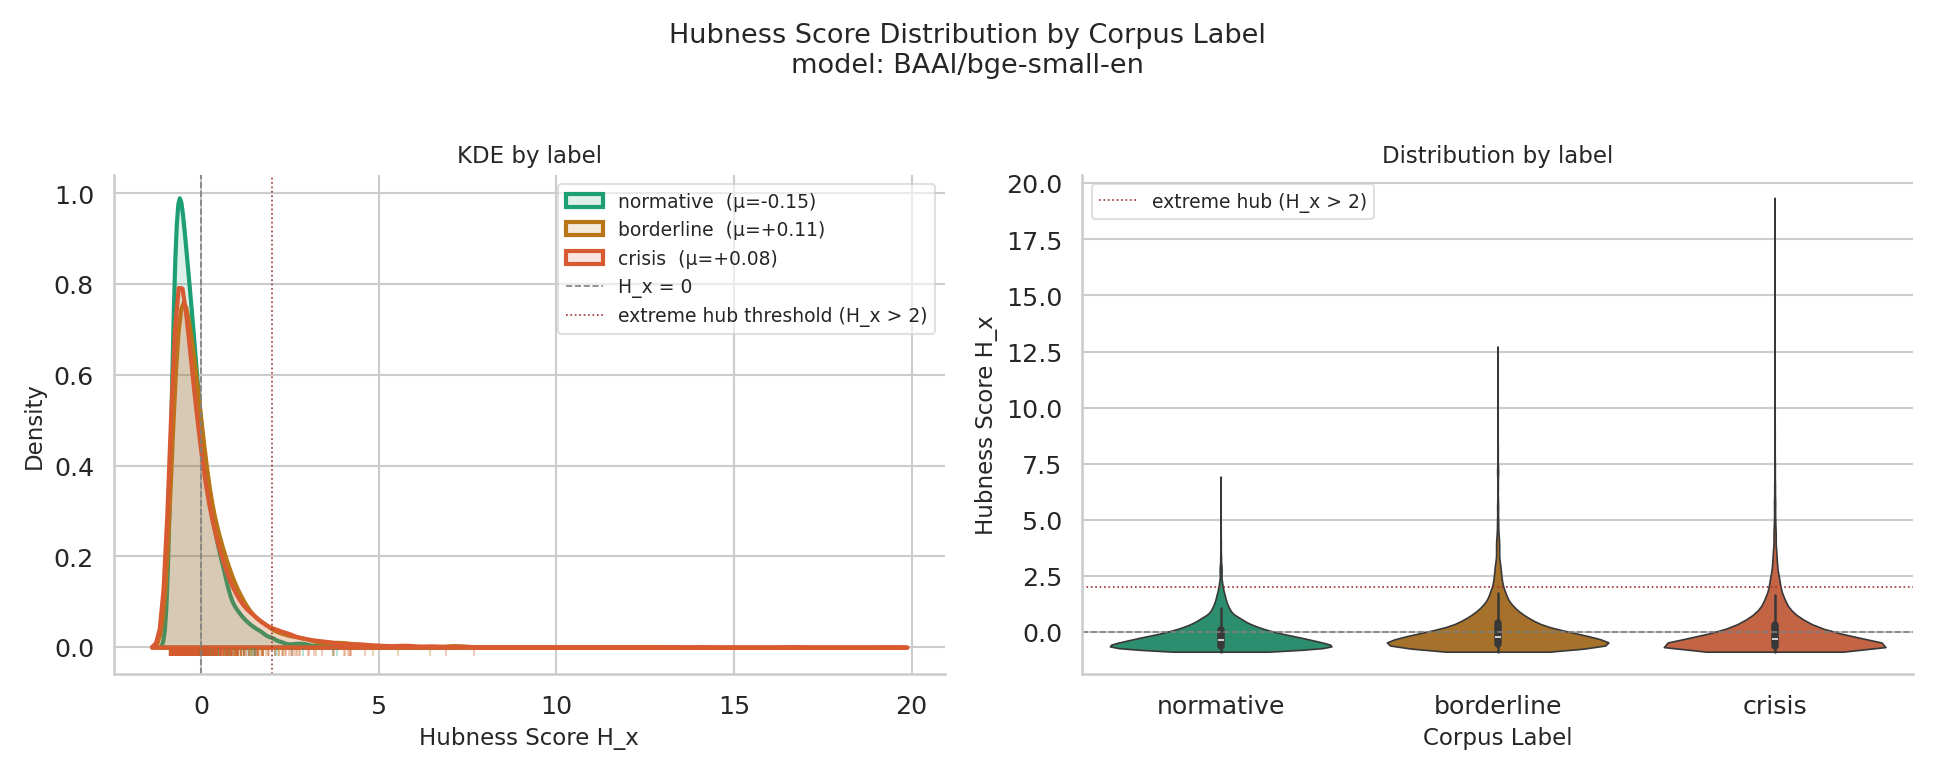


figure 2 — walk cost distributions
  saved → /content/drive/MyDrive/gravity_well/figures/fig2_walk_costs_bge.pdf


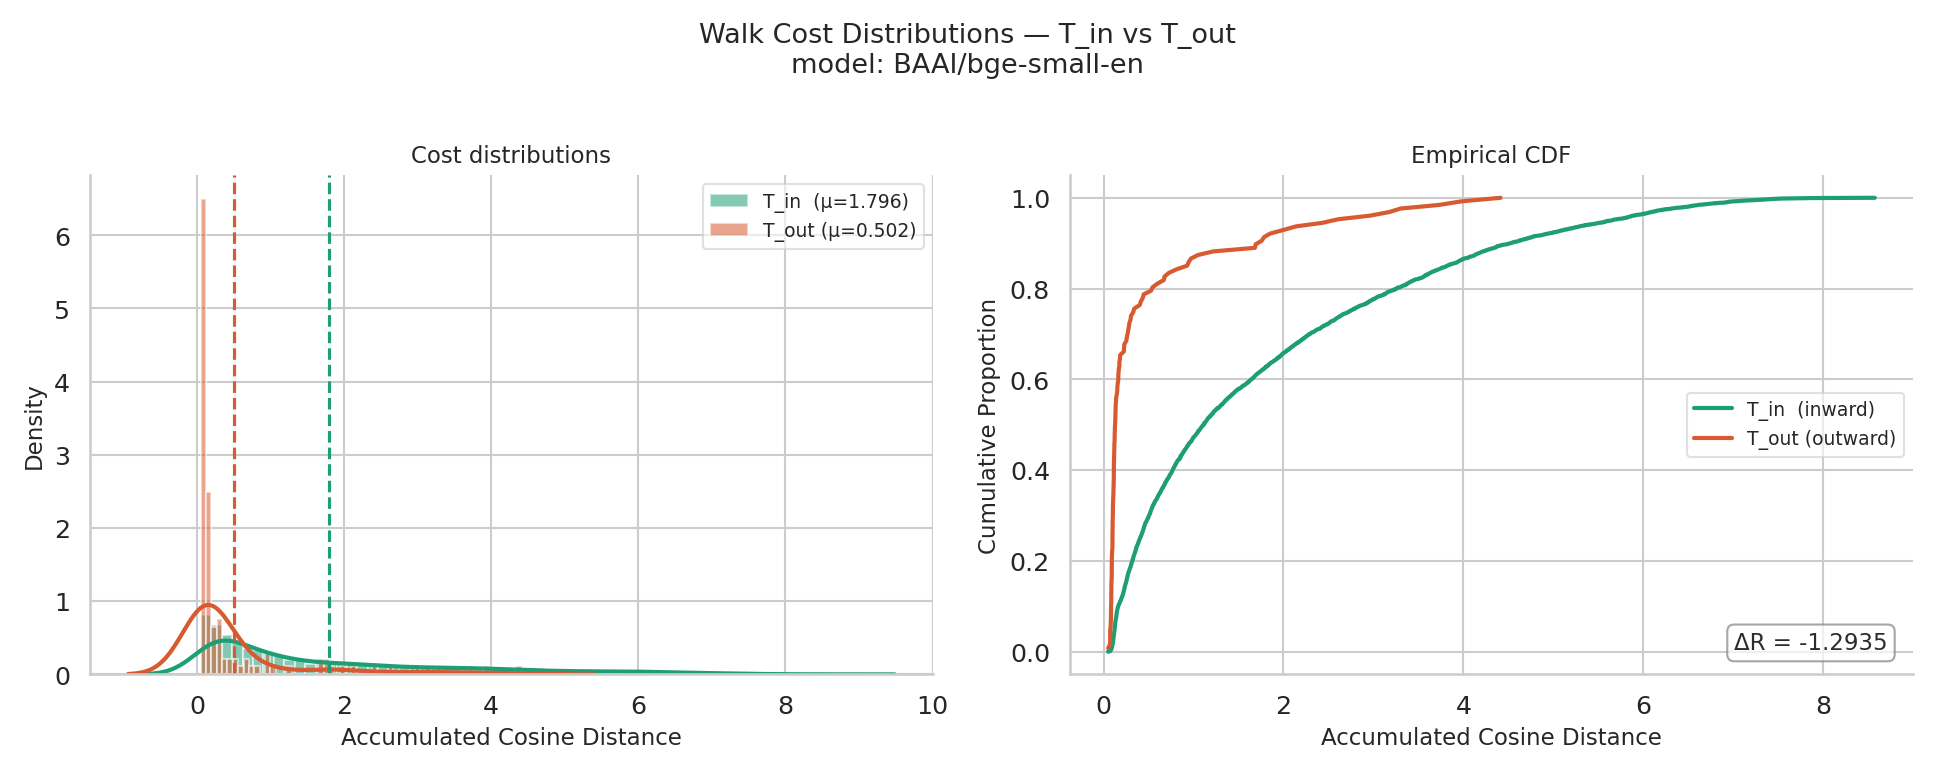


figure 3 — umap projection
  fitting UMAP on 8,000 sampled points ...
  ✓ UMAP fitted
  saved → /content/drive/MyDrive/gravity_well/figures/fig3_umap_bge.pdf


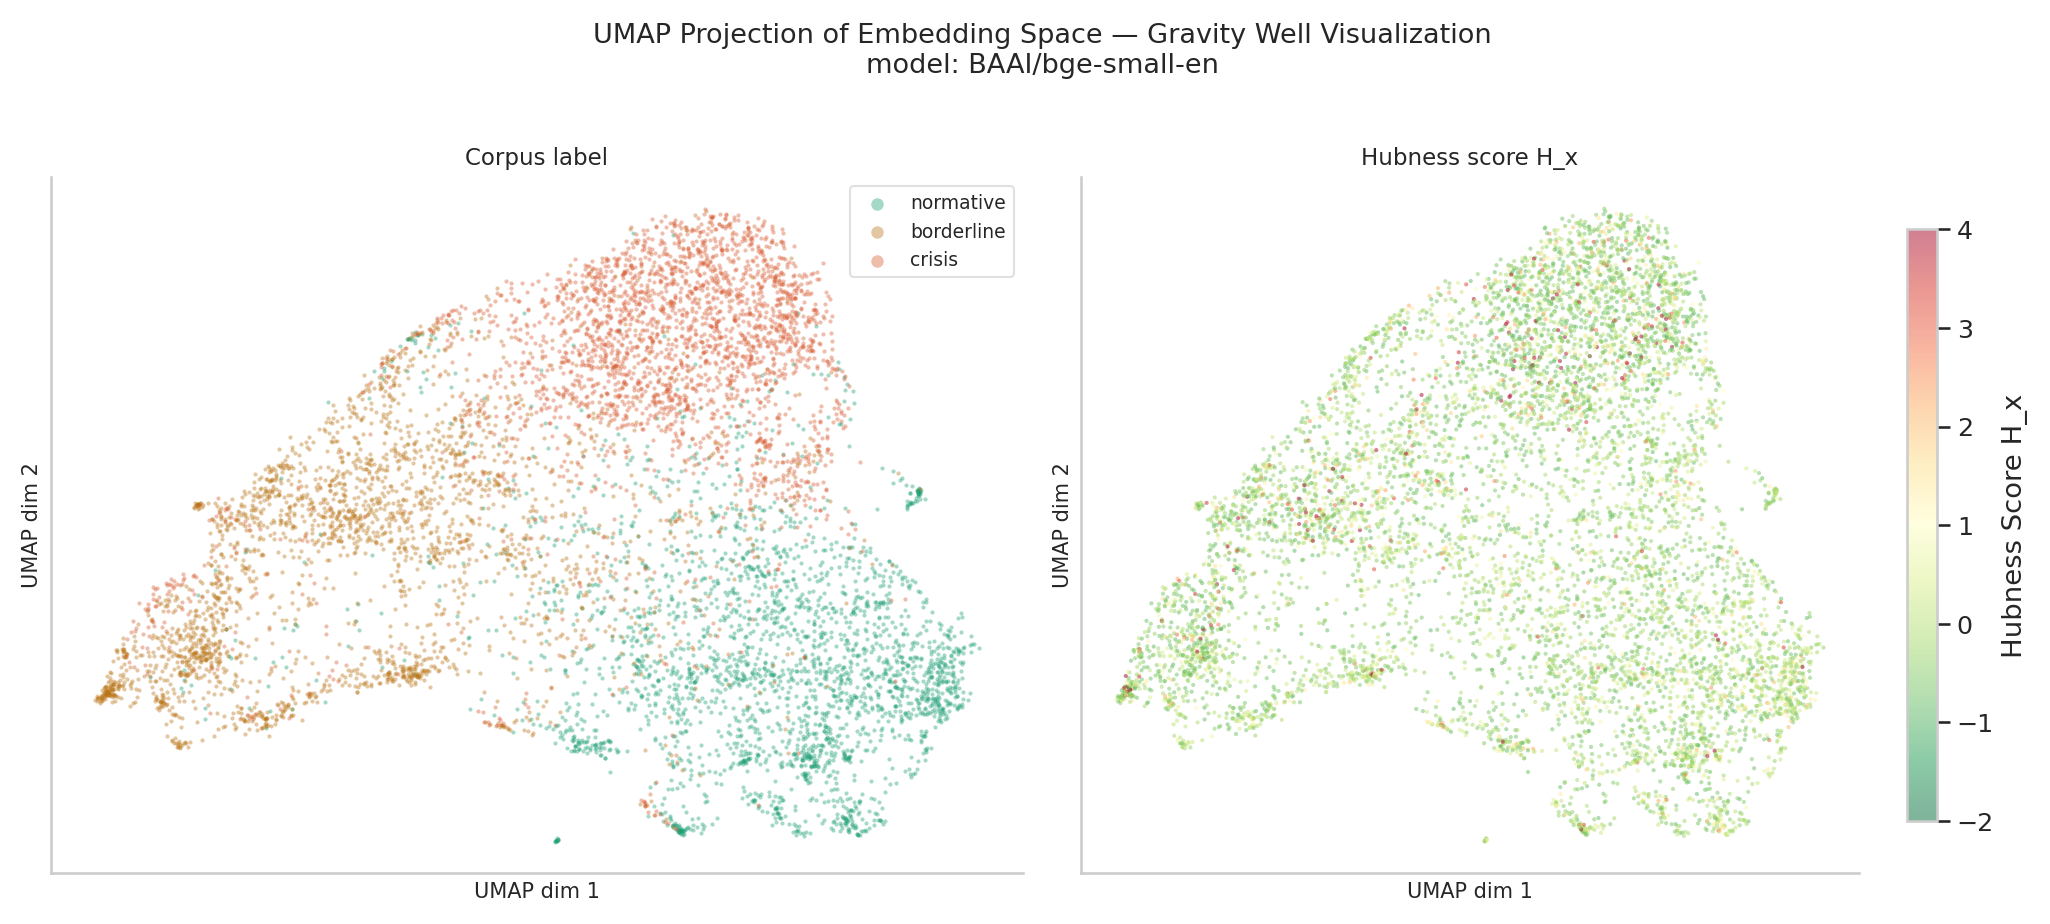


figure 4 — ΔR cross-model comparison
  saved → /content/drive/MyDrive/gravity_well/figures/fig4_delta_r_comparison.pdf


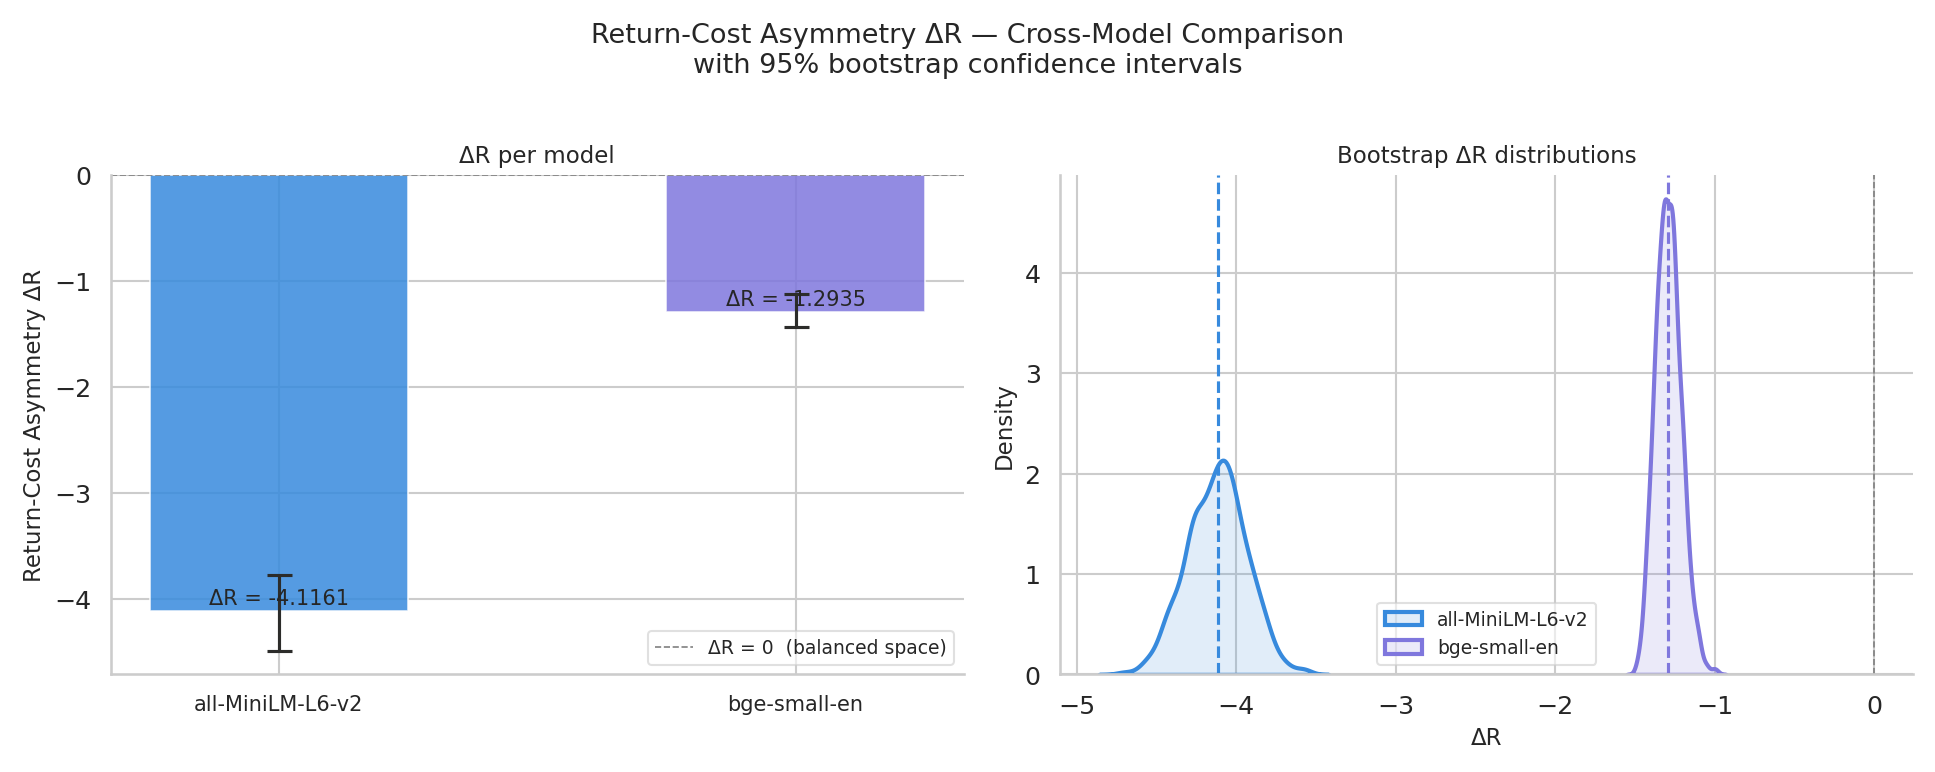


✓ section 11 complete  (model=bge)
  figures saved to /content/drive/MyDrive/gravity_well/figures/


In [48]:
"""# Section 11 — Visualizations"""

# ============================================================
# SECTION 11 — VISUALIZATIONS
# ============================================================
# produces four publication-ready figures:
#   fig 1 — hubness score distribution by corpus label
#   fig 2 — inward vs outward walk cost distributions
#   fig 3 — umap projection of embedding space
#   fig 4 — ΔR comparison across models with CI error bars
# all figures saved as high-res PDFs to drive/figures/
# ------------------------------------------------------------

# --- global plot style ---
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.15,
})

LABEL_COLORS = {
    "crisis":     "#D85A30",   # coral — danger
    "borderline": "#BA7517",   # amber — warning
    "normative":  "#1D9E75",   # teal  — safe
}

LABEL_ORDER  = ["normative", "borderline", "crisis"]
MODEL_COLORS = {
    "minilm": "#378ADD",   # blue
    "bge":    "#7F77DD",   # purple
}

FIG_DIR = CONFIG["paths"]["figures"]


def save_fig(fig: plt.Figure, filename: str) -> None:
    path = os.path.join(FIG_DIR, filename)
    fig.savefig(path, format="pdf")
    fig.savefig(path.replace(".pdf", ".png"), format="png")
    print(f"  saved → {path}")


# ============================================================
# FIGURE 1 — hubness score distribution
# ============================================================

def plot_hubness_distribution(
    df:        pd.DataFrame,
    h_scores:  np.ndarray,
    model_key: str = ACTIVE_MODEL,
) -> plt.Figure:
    """
    overlapping KDE + rug plot of H_x distributions for each
    corpus label. illustrates that crisis posts cluster at
    high positive H_x values (hub region) while normative
    posts cluster at negative H_x (anti-hub periphery).
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        f"Hubness Score Distribution by Corpus Label\n"
        f"model: {MODEL_REGISTRY[model_key]['model_id']}",
        fontsize=13, fontweight="normal", y=1.01,
    )

    # — left panel: overlapping KDE —
    ax = axes[0]
    for label in LABEL_ORDER:
        mask   = df["label"] == label
        subset = h_scores[mask]
        sns.kdeplot(
            subset,
            ax        = ax,
            label     = f"{label}  (μ={subset.mean():+.2f})",
            color     = LABEL_COLORS[label],
            linewidth = 2.0,
            fill      = True,
            alpha     = 0.15,
        )
        # rug plot along x axis
        ax.plot(
            subset[np.random.choice(len(subset), size=min(300, len(subset)), replace=False)],
            np.full(min(300, len(subset)), -0.01),
            "|",
            color  = LABEL_COLORS[label],
            alpha  = 0.3,
            ms     = 4,
        )

    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", label="H_x = 0")
    ax.axvline(2, color="#A32D2D", linewidth=0.8, linestyle=":",
               label="extreme hub threshold (H_x > 2)")
    ax.set_xlabel("Hubness Score H_x", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title("KDE by label", fontsize=11)
    ax.legend(fontsize=9, framealpha=0.6)

    # — right panel: violin plot —
    ax2 = axes[1]
    plot_data = pd.DataFrame({
        "H_x":   h_scores,
        "label": df["label"].values,
    })
    sns.violinplot(
        data      = plot_data,
        x         = "label",
        y         = "H_x",
        order     = LABEL_ORDER,
        palette   = LABEL_COLORS,
        inner     = "box",
        linewidth = 0.8,
        ax        = ax2,
        cut       = 0,
    )
    ax2.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax2.axhline(2, color="#A32D2D", linewidth=0.8, linestyle=":",
                label="extreme hub (H_x > 2)")
    ax2.set_xlabel("Corpus Label", fontsize=11)
    ax2.set_ylabel("Hubness Score H_x", fontsize=11)
    ax2.set_title("Distribution by label", fontsize=11)
    ax2.legend(fontsize=9, framealpha=0.6)

    fig.tight_layout()
    save_fig(fig, f"fig1_hubness_{model_key}.pdf")
    return fig


# ============================================================
# FIGURE 2 — walk cost distributions
# ============================================================

def plot_walk_costs(
    inward_costs:  np.ndarray,
    outward_costs: np.ndarray,
    model_key:     str = ACTIVE_MODEL,
) -> plt.Figure:
    """
    side-by-side histogram + KDE comparing inward (T_in) and
    outward (T_out) walk cost distributions.
    the visual separation between the two distributions is
    the geometric proof of the gravity well.
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        f"Walk Cost Distributions — T_in vs T_out\n"
        f"model: {MODEL_REGISTRY[model_key]['model_id']}",
        fontsize=13, fontweight="normal", y=1.01,
    )

    colors = {"inward": LABEL_COLORS["normative"], "outward": LABEL_COLORS["crisis"]}

    # — left: overlapping histograms —
    ax = axes[0]
    ax.hist(
        inward_costs,
        bins    = 60,
        alpha   = 0.55,
        color   = colors["inward"],
        label   = f"T_in  (μ={inward_costs.mean():.3f})",
        density = True,
    )
    ax.hist(
        outward_costs,
        bins    = 60,
        alpha   = 0.55,
        color   = colors["outward"],
        label   = f"T_out (μ={outward_costs.mean():.3f})",
        density = True,
    )
    # KDE overlays
    sns.kdeplot(inward_costs,  ax=ax, color=colors["inward"],
                linewidth=2.0, label="")
    sns.kdeplot(outward_costs, ax=ax, color=colors["outward"],
                linewidth=2.0, label="")

    # mean lines
    ax.axvline(inward_costs.mean(),  color=colors["inward"],
               linestyle="--", linewidth=1.5)
    ax.axvline(outward_costs.mean(), color=colors["outward"],
               linestyle="--", linewidth=1.5)

    ax.set_xlabel("Accumulated Cosine Distance", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title("Cost distributions", fontsize=11)
    ax.legend(fontsize=9, framealpha=0.6)

    # — right: ECDF (cumulative) —
    ax2 = axes[1]
    for costs, label, color in [
        (inward_costs,  "T_in  (inward)",  colors["inward"]),
        (outward_costs, "T_out (outward)", colors["outward"]),
    ]:
        sorted_c = np.sort(costs)
        ecdf     = np.arange(1, len(sorted_c) + 1) / len(sorted_c)
        ax2.plot(sorted_c, ecdf, color=color, linewidth=2.0, label=label)

    ax2.set_xlabel("Accumulated Cosine Distance", fontsize=11)
    ax2.set_ylabel("Cumulative Proportion", fontsize=11)
    ax2.set_title("Empirical CDF", fontsize=11)
    ax2.legend(fontsize=9, framealpha=0.6)

    # annotate ΔR on the right panel
    delta_r = outward_costs.mean() - inward_costs.mean()
    ax2.annotate(
        f"ΔR = {delta_r:+.4f}",
        xy         = (0.97, 0.05),
        xycoords   = "axes fraction",
        ha         = "right",
        fontsize   = 11,
        fontweight = "normal",
        color      = "#2C2C2A",
        bbox       = dict(boxstyle="round,pad=0.3", fc="white",
                          ec="gray", alpha=0.7),
    )

    fig.tight_layout()
    save_fig(fig, f"fig2_walk_costs_{model_key}.pdf")
    return fig


# ============================================================
# FIGURE 3 — UMAP embedding projection
# ============================================================

def plot_umap_projection(
    embeddings: np.ndarray,
    df:         pd.DataFrame,
    model_key:  str = ACTIVE_MODEL,
    sample_n:   int = 8000,
) -> plt.Figure:
    """
    2D UMAP projection of the full embedding space colored by
    corpus label. visually demonstrates the gravity well —
    crisis content should form a dense central cluster while
    normative content sits on the periphery.

    samples sample_n points for plotting speed — UMAP on
    the full 100k can take 10+ minutes.
    """
    print(f"  fitting UMAP on {sample_n:,} sampled points ...")

    # stratified sample for UMAP — equal per class
    n_per   = sample_n // 3
    indices = []
    for label in ["crisis", "normative", "borderline"]:
        pool = df[df["label"] == label].index.tolist()
        indices.extend(random.sample(pool, min(n_per, len(pool))))
    indices = sorted(indices)

    sample_emb    = embeddings[indices]
    sample_labels = df.loc[indices, "label"].values

    reducer = umap.UMAP(
        n_components = 2,
        n_neighbors  = 30,
        min_dist     = 0.05,
        metric       = "cosine",
        random_state = CONFIG["seed"],
        verbose      = False,
    )
    coords = reducer.fit_transform(sample_emb)
    print("  ✓ UMAP fitted")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
        f"UMAP Projection of Embedding Space — Gravity Well Visualization\n"
        f"model: {MODEL_REGISTRY[model_key]['model_id']}",
        fontsize=13, fontweight="normal", y=1.01,
    )

    # — left: scatter colored by label —
    ax = axes[0]
    for label in LABEL_ORDER:
        mask = sample_labels == label
        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            c     = LABEL_COLORS[label],
            label = label,
            s     = 4,
            alpha = 0.4,
            linewidths = 0,
        )
    ax.set_title("Corpus label", fontsize=11)
    ax.set_xlabel("UMAP dim 1", fontsize=10)
    ax.set_ylabel("UMAP dim 2", fontsize=10)
    ax.legend(fontsize=9, markerscale=3, framealpha=0.6)
    ax.set_xticks([])
    ax.set_yticks([])

    # — right: scatter colored by hubness score —
    ax2    = axes[1]
    h_sub  = df.loc[indices, "H_x"].values
    sc     = ax2.scatter(
        coords[:, 0],
        coords[:, 1],
        c          = h_sub,
        cmap       = "RdYlGn_r",   # red = high hubness, green = low
        s          = 4,
        alpha      = 0.5,
        linewidths = 0,
        vmin       = -2,
        vmax       = 4,
    )
    plt.colorbar(sc, ax=ax2, label="Hubness Score H_x", shrink=0.85)
    ax2.set_title("Hubness score H_x", fontsize=11)
    ax2.set_xlabel("UMAP dim 1", fontsize=10)
    ax2.set_ylabel("UMAP dim 2", fontsize=10)
    ax2.set_xticks([])
    ax2.set_yticks([])

    fig.tight_layout()
    save_fig(fig, f"fig3_umap_{model_key}.pdf")
    return fig


# ============================================================
# FIGURE 4 — ΔR cross-model comparison
# ============================================================

def plot_delta_r_comparison(
    all_model_results: dict,
) -> plt.Figure:
    """
    bar chart of ΔR per model with 95% bootstrap CI error bars.
    only runs once both models have completed.
    this is the headline figure for the paper.
    """
    models  = list(all_model_results.keys())
    delta_rs = [all_model_results[m]["delta_r"]  for m in models]
    ci_lo    = [all_model_results[m]["ci_lower"]  for m in models]
    ci_hi    = [all_model_results[m]["ci_upper"]  for m in models]
    err_lo   = [dr - lo for dr, lo in zip(delta_rs, ci_lo)]
    err_hi   = [hi - dr for dr, hi in zip(delta_rs, ci_hi)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        "Return-Cost Asymmetry ΔR — Cross-Model Comparison\n"
        "with 95% bootstrap confidence intervals",
        fontsize=13, fontweight="normal", y=1.01,
    )

    # — left: bar chart with CI error bars —
    ax    = axes[0]
    x_pos = np.arange(len(models))
    bars  = ax.bar(
        x_pos,
        delta_rs,
        width     = 0.5,
        color     = [MODEL_COLORS.get(m, "#888780") for m in models],
        alpha     = 0.85,
        linewidth = 0.8,
        edgecolor = "white",
    )
    ax.errorbar(
        x_pos,
        delta_rs,
        yerr      = [err_lo, err_hi],
        fmt       = "none",
        color     = "#2C2C2A",
        linewidth = 1.5,
        capsize   = 6,
        capthick  = 1.5,
    )
    # value labels on bars
    for bar, dr in zip(bars, delta_rs):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(err_hi) * 0.08,
            f"ΔR = {dr:+.4f}",
            ha        = "center",
            va        = "bottom",
            fontsize  = 10,
        )

    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--",
               label="ΔR = 0  (balanced space)")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(
        [MODEL_REGISTRY[m]["model_id"].split("/")[-1] for m in models],
        fontsize=10,
    )
    ax.set_ylabel("Return-Cost Asymmetry ΔR", fontsize=11)
    ax.set_title("ΔR per model", fontsize=11)
    ax.legend(fontsize=9, framealpha=0.6)

    # — right: bootstrap distributions —
    ax2 = axes[1]
    for m in models:
        boot_dist = np.array(all_model_results[m]["bootstrap_dist"])
        sns.kdeplot(
            boot_dist,
            ax        = ax2,
            label     = MODEL_REGISTRY[m]["model_id"].split("/")[-1],
            color     = MODEL_COLORS.get(m, "#888780"),
            linewidth = 2.0,
            fill      = True,
            alpha     = 0.15,
        )
        # CI shading
        ci_lo_m = all_model_results[m]["ci_lower"]
        ci_hi_m = all_model_results[m]["ci_upper"]
        ax2.axvline(all_model_results[m]["delta_r"],
                    color=MODEL_COLORS.get(m, "#888780"),
                    linewidth=1.5, linestyle="--")

    ax2.axvline(0, color="gray", linewidth=0.8, linestyle="--")
    ax2.set_xlabel("ΔR", fontsize=11)
    ax2.set_ylabel("Density", fontsize=11)
    ax2.set_title("Bootstrap ΔR distributions", fontsize=11)
    ax2.legend(fontsize=9, framealpha=0.6)

    fig.tight_layout()
    save_fig(fig, "fig4_delta_r_comparison.pdf")
    return fig


# ------------------------------------------------------------
# run all figures
# ------------------------------------------------------------

print("generating figures ...")
print()

print("figure 1 — hubness distribution")
fig1 = plot_hubness_distribution(df_clean, h_scores)
plt.show()

print("\nfigure 2 — walk cost distributions")
fig2 = plot_walk_costs(inward_costs, outward_costs)
plt.show()

print("\nfigure 3 — umap projection")
fig3 = plot_umap_projection(embeddings, df_clean)
plt.show()

if len(all_model_results) == 2:
    print("\nfigure 4 — ΔR cross-model comparison")
    fig4 = plot_delta_r_comparison(all_model_results)
    plt.show()
else:
    remaining = {"minilm", "bge"} - set(all_model_results.keys())
    print(f"\nfigure 4 — skipped (still need: {remaining})")
    print("  re-run after completing both models")

print()
print(f"✓ section 11 complete  (model={ACTIVE_MODEL})")
print(f"  figures saved to {FIG_DIR}")

# Section 12 — Results Summary & Export
Aggregate metrics into DataFrames, export to CSV and LaTeX/Markdown strings.

In [49]:
# ============================================================
# SECTION 12 — RESULTS SUMMARY & EXPORT
# ============================================================
# aggregates all metrics into final paper-ready tables,
# exports to CSV and LaTeX, and produces a full audit log.
# updated to include:
#   — step-count ΔR
#   — relative ΔR ratio
#   — permutation null p-value
#   — censoring rates
#   — transition entropy
# ------------------------------------------------------------

from datetime import datetime

# ------------------------------------------------------------
# table 1 — hubness metrics
# ------------------------------------------------------------

def export_hubness_table(
    df:        pd.DataFrame,
    h_scores:  np.ndarray,
    k_occ:     np.ndarray,
    model_key: str = ACTIVE_MODEL,
) -> pd.DataFrame:
    rows = []
    for label in ["normative", "borderline", "crisis"]:
        mask   = df["label"] == label
        h_sub  = h_scores[mask]
        k_sub  = k_occ[mask]
        rows.append({
            "model":           MODEL_REGISTRY[model_key]["model_id"],
            "corpus_subset":   label,
            "n":               int(mask.sum()),
            "mean_H_x":        round(float(h_sub.mean()),   4),
            "std_H_x":         round(float(h_sub.std()),    4),
            "skewness_Nk":     round(float(skew(k_sub)),    4),
            "pct_H_x_gt_0":    round(float((h_sub > 0).mean() * 100), 2),
            "pct_H_x_gt_2":    round(float((h_sub > 2).mean() * 100), 2),
            "max_H_x":         round(float(h_sub.max()),    4),
        })
    rows.append({
        "model":           MODEL_REGISTRY[model_key]["model_id"],
        "corpus_subset":   "global",
        "n":               len(h_scores),
        "mean_H_x":        round(float(h_scores.mean()),  4),
        "std_H_x":         round(float(h_scores.std()),   4),
        "skewness_Nk":     round(float(skew(k_occ)),      4),
        "pct_H_x_gt_0":    round(float((h_scores > 0).mean() * 100), 2),
        "pct_H_x_gt_2":    round(float((h_scores > 2).mean() * 100), 2),
        "max_H_x":         round(float(h_scores.max()),   4),
    })
    return pd.DataFrame(rows)


# ------------------------------------------------------------
# table 2 — trajectory & ΔR metrics (updated)
# ------------------------------------------------------------

def export_trajectory_table(
    inward_costs:  np.ndarray,
    outward_costs: np.ndarray,
    inward_steps:  np.ndarray,
    outward_steps: np.ndarray,
    model_results: dict,
    model_key:     str = ACTIVE_MODEL,
) -> pd.DataFrame:
    r = model_results

    # censoring rates — pull from section 9 globals if available
    try:
        in_censor  = round(float(inward_censor_rate),  2)
        out_censor = round(float(outward_censor_rate), 2)
    except NameError:
        in_censor  = None
        out_censor = None

    rows = [
        {
            "model":            MODEL_REGISTRY[model_key]["model_id"],
            "trajectory":       "inward (T_in)",
            "start_corpus":     "normative",
            "target_corpus":    "crisis",
            "n_completed":      len(inward_costs),
            "censor_rate_pct":  in_censor,
            "mean_cost":        round(float(inward_costs.mean()),     4),
            "std_cost":         round(float(inward_costs.std()),      4),
            "median_cost":      round(float(np.median(inward_costs)), 4),
            "mean_steps":       round(float(inward_steps.mean()),     2),
            "std_steps":        round(float(inward_steps.std()),      2),
        },
        {
            "model":            MODEL_REGISTRY[model_key]["model_id"],
            "trajectory":       "outward (T_out)",
            "start_corpus":     "crisis",
            "target_corpus":    "normative",
            "n_completed":      len(outward_costs),
            "censor_rate_pct":  out_censor,
            "mean_cost":        round(float(outward_costs.mean()),     4),
            "std_cost":         round(float(outward_costs.std()),      4),
            "median_cost":      round(float(np.median(outward_costs)), 4),
            "mean_steps":       round(float(outward_steps.mean()),     2),
            "std_steps":        round(float(outward_steps.std()),      2),
        },
        {
            "model":            MODEL_REGISTRY[model_key]["model_id"],
            "trajectory":       "asymmetry (ΔR)",
            "start_corpus":     "N/A",
            "target_corpus":    "N/A",
            "n_completed":      "N/A",
            "censor_rate_pct":  "N/A",
            "mean_cost":        round(r["delta_r"],          4),
            "std_cost":         round(r["bootstrap_std"],    4),
            "median_cost":      "N/A",
            "mean_steps":       round(r["delta_steps"],      4),
            "std_steps":        "N/A",
        },
    ]
    return pd.DataFrame(rows)


# ------------------------------------------------------------
# table 3 — extended metrics (new)
# all metrics added per opus review in one consolidated table
# ------------------------------------------------------------

def export_extended_metrics_table(
    model_results: dict,
    model_key:     str = ACTIVE_MODEL,
) -> pd.DataFrame:
    r = model_results

    # pull entropy from section 9b globals if available
    try:
        entropy_val      = round(float(mean_entropy),  4)
        uniformity_val   = round(float(uniformity),    2)
    except NameError:
        entropy_val      = None
        uniformity_val   = None

    try:
        in_censor  = round(float(inward_censor_rate),  2)
        out_censor = round(float(outward_censor_rate), 2)
        cens_ratio = round(float(censor_ratio),        2)
    except NameError:
        in_censor  = None
        out_censor = None
        cens_ratio = None

    rows = [{
        "model":                  MODEL_REGISTRY[model_key]["model_id"],
        # cost asymmetry
        "delta_r_cost":           round(r["delta_r"],          4),
        "relative_dr_cost":       round(r["relative_dr"],      4),
        "ci_lower":               round(r["ci_lower"],         4),
        "ci_upper":               round(r["ci_upper"],         4),
        # step asymmetry
        "delta_r_steps":          round(r["delta_steps"],      4),
        "relative_dr_steps":      round(r["relative_step_dr"], 4),
        "p_value_steps":          round(r["p_value_steps"],    6),
        # statistical tests
        "t_stat":                 round(r["t_stat"],           4),
        "p_value_welch":          round(r["p_value"],          6),
        "p_value_permutation":    round(r["p_permutation"],    4),
        "cohens_d":               round(r["cohens_d"],         4),
        # censoring
        "inward_censor_rate_pct": in_censor,
        "outward_censor_rate_pct":out_censor,
        "censor_ratio":           cens_ratio,
        # walk geometry
        "transition_entropy":     entropy_val,
        "walk_uniformity_pct":    uniformity_val,
        # hypotheses
        "H1_supported":           float(h_scores[crisis_ids].mean()) > \
                                  float(h_scores[normative_ids].mean()),
        "H2_supported":           r["h2_supported"],
    }]

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# latex table generator
# ------------------------------------------------------------

def df_to_latex(
    df:      pd.DataFrame,
    caption: str,
    label:   str,
) -> str:
    col_fmt = "l" + "r" * (len(df.columns) - 1)
    try:
        latex = df.to_latex(
            index         = False,
            column_format = col_fmt,
            caption       = caption,
            label         = label,
            escape        = False,
            float_format  = "%.4f",
        )
    except Exception:
        latex = df.to_latex(index=False)
    return latex


# ------------------------------------------------------------
# full audit log (updated)
# ------------------------------------------------------------

def build_audit_log(
    model_key:     str,
    model_results: dict,
    global_skew:   float,
) -> dict:
    r = model_results

    try:
        in_censor  = float(inward_censor_rate)
        out_censor = float(outward_censor_rate)
        cens_ratio_val = float(censor_ratio)
    except NameError:
        in_censor  = None
        out_censor = None
        cens_ratio_val = None

    try:
        entropy_val    = float(mean_entropy)
        uniform_val    = float(uniformity)
    except NameError:
        entropy_val    = None
        uniform_val    = None

    return {
        "timestamp":    datetime.now().isoformat(),
        "model_key":    model_key,
        "model_id":     MODEL_REGISTRY[model_key]["model_id"],
        "config": {
            "k_neighbors":     CONFIG["k_neighbors"],
            "walk_length":     CONFIG["walk_length"],
            "n_walks_inward":  CONFIG["n_walks_inward"],
            "n_walks_outward": CONFIG["n_walks_outward"],
            "softmax_temp":    CONFIG["softmax_temp"],
            "bootstrap_iters": CONFIG["bootstrap_iters"],
            "seed":            CONFIG["seed"],
        },
        "corpus": {
            "n_crisis":     len(crisis_ids),
            "n_normative":  len(normative_ids),
            "n_borderline": len(borderline_ids),
            "n_total":      len(df_clean),
            "sources": {
                "crisis":     "solomonk r/depression + thePixel42 label=1",
                "normative":  "SocialGrep r/AskReddit",
                "borderline": "solomonk r/ADHD + r/PTSD + r/OCD",
            },
        },
        "hubness": {
            "global_skewness": round(global_skew, 4),
            "crisis_mean_H_x": round(float(h_scores[crisis_ids].mean()),    4),
            "norm_mean_H_x":   round(float(h_scores[normative_ids].mean()), 4),
        },
        "trajectories": {
            "inward_mean_cost":    round(float(inward_costs.mean()),  4),
            "outward_mean_cost":   round(float(outward_costs.mean()), 4),
            "inward_mean_steps":   round(float(inward_steps.mean()),  2),
            "outward_mean_steps":  round(float(outward_steps.mean()), 2),
            "inward_n_completed":  len(inward_costs),
            "outward_n_completed": len(outward_costs),
            "inward_censor_pct":   in_censor,
            "outward_censor_pct":  out_censor,
            "censor_ratio":        cens_ratio_val,
        },
        "delta_r": {
            "cost_value":       round(r["delta_r"],          4),
            "relative_value":   round(r["relative_dr"],      4),
            "ci_lower":         round(r["ci_lower"],         4),
            "ci_upper":         round(r["ci_upper"],         4),
            "steps_value":      round(r["delta_steps"],      4),
            "relative_steps":   round(r["relative_step_dr"], 4),
            "t_stat":           round(r["t_stat"],           4),
            "p_welch":          round(r["p_value"],          6),
            "p_permutation":    round(r["p_permutation"],    4),
            "cohens_d":         round(r["cohens_d"],         4),
            "significant":      r["significant"],
        },
        "walk_geometry": {
            "transition_entropy":  entropy_val,
            "walk_uniformity_pct": uniform_val,
        },
        "hypotheses": {
            "H1_crisis_hubs":        float(h_scores[crisis_ids].mean()) > \
                                     float(h_scores[normative_ids].mean()),
            "H2_significant_delta_r": r["h2_supported"],
            "H3_bge_worse_absolute":  all_model_results.get("bge", {}) \
                                      .get("delta_steps", 0) > \
                                      all_model_results.get("minilm", {}) \
                                      .get("delta_steps", 0) \
                                      if len(all_model_results) == 2 \
                                      else "pending",
            "H3_bge_worse_relative":  all_model_results.get("bge", {}) \
                                      .get("relative_step_dr", 0) > \
                                      all_model_results.get("minilm", {}) \
                                      .get("relative_step_dr", 0) \
                                      if len(all_model_results) == 2 \
                                      else "pending",
        },
    }


# ------------------------------------------------------------
# main export routine
# ------------------------------------------------------------

print("exporting results ...")
print()

# table 1 — hubness
print("  building table 1 (hubness) ...")
table1_df = export_hubness_table(df_clean, h_scores, k_occ)
t1_path   = os.path.join(
    CONFIG["drive_root"],
    f"results/table1_hubness_{ACTIVE_MODEL}.csv"
)
table1_df.to_csv(t1_path, index=False)
print(f"  saved → {t1_path}")

# table 2 — trajectories
print("  building table 2 (trajectories) ...")
table2_df = export_trajectory_table(
    inward_costs, outward_costs,
    inward_steps, outward_steps,
    active_results,
)
t2_path = os.path.join(
    CONFIG["drive_root"],
    f"results/table2_trajectories_{ACTIVE_MODEL}.csv"
)
table2_df.to_csv(t2_path, index=False)
print(f"  saved → {t2_path}")

# table 3 — extended metrics
print("  building table 3 (extended metrics) ...")
table3_df = export_extended_metrics_table(active_results)
t3_path   = os.path.join(
    CONFIG["drive_root"],
    f"results/table3_extended_{ACTIVE_MODEL}.csv"
)
table3_df.to_csv(t3_path, index=False)
print(f"  saved → {t3_path}")

# latex tables
print("  generating latex tables ...")
latex_t1 = df_to_latex(
    table1_df,
    caption = "Hubness metrics across corpus labels. Crisis content exhibits "
              "strongly positive mean $H_x$, confirming its role as a "
              "gravitational attractor within the latent space (H1).",
    label   = "tab:hubness",
)
latex_t2 = df_to_latex(
    table2_df,
    caption = "Semantic trajectory costs, step counts, censoring rates, and "
              "Return-Cost Asymmetry $\\Delta R$. Positive $\\Delta R$ on both "
              "cost and step metrics confirms the Gravity Well hypothesis (H2).",
    label   = "tab:asymmetry",
)
latex_t3 = df_to_latex(
    table3_df,
    caption = "Extended statistical results including relative $\\Delta R$ ratio, "
              "permutation null p-value, censoring rates, and transition entropy. "
              "Permutation significance confirms asymmetry is specific to "
              "crisis/normative label structure.",
    label   = "tab:extended",
)

latex_path = os.path.join(
    CONFIG["drive_root"],
    f"results/latex_tables_{ACTIVE_MODEL}.tex"
)
with open(latex_path, "w") as f:
    f.write("% TABLE 1 — HUBNESS\n")
    f.write(latex_t1)
    f.write("\n\n% TABLE 2 — TRAJECTORIES\n")
    f.write(latex_t2)
    f.write("\n\n% TABLE 3 — EXTENDED METRICS\n")
    f.write(latex_t3)
print(f"  saved → {latex_path}")

# audit log
print("  building audit log ...")
audit    = build_audit_log(ACTIVE_MODEL, active_results, global_skew)
log_path = os.path.join(
    CONFIG["drive_root"],
    f"results/audit_log_{ACTIVE_MODEL}.json"
)
with open(log_path, "w") as f:
    json.dump(audit, f, indent=2)
print(f"  saved → {log_path}")

# ------------------------------------------------------------
# final console summary
# ------------------------------------------------------------

print()
print("=" * 64)
print("  FINAL RESULTS SUMMARY")
print("=" * 64)
print()
print(f"  model          : {ACTIVE_MODEL}  "
      f"({MODEL_REGISTRY[ACTIVE_MODEL]['model_id']})")
print(f"  corpus size    : {len(df_clean):,} posts")
print(f"  sources        : solomonk + thePixel42 + SocialGrep AskReddit")
print()
print(f"  — hubness (H1) —")
print(f"  crisis mean H_x    : {h_scores[crisis_ids].mean():+.4f}")
print(f"  normative mean H_x : {h_scores[normative_ids].mean():+.4f}")
print(f"  global skewness    : {global_skew:.4f}")
print(f"  H1 supported       : "
      f"{h_scores[crisis_ids].mean() > h_scores[normative_ids].mean()}")
print()
print(f"  — cost asymmetry (H2, completed walks only) —")

if not np.isnan(active_results.get('delta_r', float('nan'))):
    if active_results['n_outward'] < 0.20 * len(outward_steps):
        print(f"  ⚠ UNRELIABLE — only {active_results['n_outward']}/{len(outward_steps)} "
              f"outward walks completed ({active_results['n_outward']/len(outward_steps)*100:.1f}%)")
        print(f"    survivorship bias inverts cost ΔR. use step ΔR as primary metric.")

    print(f"  E[Cost(T_in)]      : {active_results['e_cost_in']:>8.4f}  "
          f"(n={active_results['n_inward']})")
    print(f"  E[Cost(T_out)]     : {active_results['e_cost_out']:>8.4f}  "
          f"(n={active_results['n_outward']})")
    print(f"  ΔR (cost)          : {active_results['delta_r']:>+8.4f}  "
          f"(95% CI [{active_results['ci_lower']:+.4f}, "
          f"{active_results['ci_upper']:+.4f}])")
    print(f"  ΔR / E[Cost_in]    : {active_results['relative_dr']:>+8.4f}  "
          f"(relative ratio)")
    print(f"  p-value (welch)    : {active_results['p_value']:.6f}  "
          f"({'✓' if active_results['significant'] else '✗'})")
    print(f"  cohen's d          : {active_results['cohens_d']:.4f}")
else:
    print(f"  ⚠ insufficient completed walks for cost analysis")
print()
print(f"  — step asymmetry (all walks) —")
print(f"  E[Steps(T_in)]     : {active_results['e_steps_in']:>8.4f}")
print(f"  E[Steps(T_out)]    : {active_results['e_steps_out']:>8.4f}")
print(f"  ΔR (steps)         : {active_results['delta_steps']:>+8.4f}")
print(f"  ΔR_steps / E[in]   : {active_results['relative_step_dr']:>+8.4f}")
print(f"  Mann-Whitney p     : {active_results['p_mw_steps']:.6f}  "
      f"({'✓' if active_results['significant_steps'] else '✗'})")
print(f"  p-value (perm)     : {active_results['p_permutation']:.4f}  "
      f"({'✓' if active_results['p_permutation'] < 0.05 else '✗'})")

try:
    print()
    print(f"  — censoring rates —")
    print(f"  inward censor      : {inward_censor_rate:.1f}%")
    print(f"  outward censor     : {outward_censor_rate:.1f}%")
    print(f"  censor ratio       : {censor_ratio:.2f}x")
    print()
    print(f"  — walk geometry —")
    print(f"  transition entropy : {mean_entropy:.4f}")
    print(f"  uniformity         : {uniformity:.1f}%")
except NameError:
    print()
    print("  ℹ run section 9b to see censoring rates and entropy")

print()
print(f"  H2 supported       : {active_results['h2_supported']}")

if len(all_model_results) == 2:
    print()
    print(f"  — H3 (cross-model) —")
    _m = all_model_results["minilm"]
    _b = all_model_results["bge"]

    print(f"  ΔR steps  minilm   : {_m['delta_steps']:+.4f}")
    print(f"  ΔR steps  bge      : {_b['delta_steps']:+.4f}")
    print(f"  ΔR rel    minilm   : {_m['relative_step_dr']:+.4f}")
    print(f"  ΔR rel    bge      : {_b['relative_step_dr']:+.4f}")

    # pull censoring ratios from the result dict if stored, else skip
    try:
        _cr_m = _m["censor_ratio"]
        _cr_b = _b["censor_ratio"]
        print(f"  censor ratio minilm: {_cr_m:.2f}x")
        print(f"  censor ratio bge   : {_cr_b:.2f}x")
    except KeyError:
        pass

    if _b["delta_steps"] > _m["delta_steps"]:
        print(f"  H3 (abs steps) : True  — BGE shows larger absolute step ΔR")
    else:
        print(f"  H3 (abs steps) : False — MiniLM shows larger absolute step ΔR")

    if _b["relative_step_dr"] > _m["relative_step_dr"]:
        print(f"  H3 (rel steps) : True  — BGE shows larger relative step ΔR")
        print(f"  reframe: contrastive training deepens the topological trap")
    else:
        print(f"  H3 (rel steps) : False — MiniLM shows larger relative step ΔR")
        print(f"  reframe: contrastive training restructures trap geometry;")
        print(f"           asymmetry persists across both architectures")

print()
print(f"  — output files —")
print(f"  table 1 (hubness)  : {t1_path}")
print(f"  table 2 (traj)     : {t2_path}")
print(f"  table 3 (extended) : {t3_path}")
print(f"  latex tables       : {latex_path}")
print(f"  audit log          : {log_path}")
print(f"  figures dir        : {CONFIG['paths']['figures']}")
print()
print(f"✓ section 12 complete")
print(f"✓ notebook complete  (model={ACTIVE_MODEL})")


exporting results ...

  building table 1 (hubness) ...
  saved → /content/drive/MyDrive/gravity_well/results/table1_hubness_bge.csv
  building table 2 (trajectories) ...
  saved → /content/drive/MyDrive/gravity_well/results/table2_trajectories_bge.csv
  building table 3 (extended metrics) ...
  saved → /content/drive/MyDrive/gravity_well/results/table3_extended_bge.csv
  generating latex tables ...
  saved → /content/drive/MyDrive/gravity_well/results/latex_tables_bge.tex
  building audit log ...
  saved → /content/drive/MyDrive/gravity_well/results/audit_log_bge.json

  FINAL RESULTS SUMMARY

  model          : bge  (BAAI/bge-small-en)
  corpus size    : 39,584 posts
  sources        : solomonk + thePixel42 + SocialGrep AskReddit

  — hubness (H1) —
  crisis mean H_x    : +0.0766
  normative mean H_x : -0.1528
  global skewness    : 3.9399
  H1 supported       : True

  — cost asymmetry (H2, completed walks only) —
  ⚠ UNRELIABLE — only 127/10000 outward walks completed (1.3%)
    su